In [54]:
# ==========================================
# 1. Imports and Setup
# ==========================================
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from typing import List

import random
import os
import time
import torch
import torch.nn as nn
import copy

# Import your modules
from rnn_model import PLRNN, compute_accuracies, get_latent_states
from MAR import regularization_loss
from Dataset import MultiTaskDataset, CognitiveTask, DelayedResponse, ReactionTime, collate_fn, ContinuousMultitaskDataset, MultiTaskDataset, CopyTask
from analysis_functions import bitcode_distribution, plot_bitcode_distribution

# Set Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

Running on: cpu


In [55]:
def plot_method_averages(results, num_tasks, model_params=None, task_names=None, save_plot=True):
    """
    Plots the mean accuracy and 1x standard deviation band across all runs.
    Defaults to saving the plot in a 'plots' folder.
    """
    # 1. Setup Layout
    fig, axes = plt.subplots(1, num_tasks, figsize=(6 * num_tasks, 6))
    if num_tasks == 1: axes = [axes] 

    fig.suptitle(f"Results for: ALRNN (M={model_params.get('M', 30)}, L={model_params.get('L', 8)})\nMean ± 1 Std Dev (Across All Runs per Method)", fontsize=14)

    # 2. Get Time Axis & Switch Points
    first_key = list(results.keys())[0]
    if 'acc_task1' not in results[first_key]:
        print("Error: Results dictionary missing 'acc_task1'.")
        return

    epochs_total = len(results[first_key]['acc_task1'])
    x_axis = np.arange(epochs_total)
    
    switch_interval = epochs_total // num_tasks
    switch_points = [i * switch_interval for i in range(1, num_tasks)]

    # 3. Configure Axes
    for i, ax in enumerate(axes):
        task_num = i + 1
        ax.set_title(f"Model Accuracy on {task_names[i]}")
        ax.set_xlabel("Epochs")
        ax.set_ylabel("Accuracy")
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-0.05, 1.05) 
        
        for sp in switch_points:
            ax.axvline(sp, color='k', linestyle=':', alpha=0.5)
            
        start = (task_num - 1) * switch_interval
        end = task_num * switch_interval

    # 4. Group Data by Method across ALL runs
    grouped_data = {"No EWC": [], "EWC": [], "EWC ls": [], "EWC approx": [], "EWC approx diag": []}
    for key, res in results.items():
        if "No EWC" in key:
            grouped_data["No EWC"].append(res)
        elif "EWC approx diag" in key:
            grouped_data["EWC approx diag"].append(res)
        elif "EWC ls" in key:
            grouped_data["EWC ls"].append(res)
        elif "EWC approx" in key:
            grouped_data["EWC approx"].append(res)
        elif "EWC" in key:
            grouped_data["EWC"].append(res)

    # 5. Calculate and Plot Mean + Std Band per Method
    colors = {"No EWC": "tab:blue", "EWC": "tab:orange", "EWC ls": "tab:green", "EWC approx": "tab:red", "EWC approx diag": "tab:purple"}
    styles = {"No EWC": "--", "EWC": "-", "EWC ls": "-.", "EWC approx": ":", "EWC approx diag": "-."}

    for method, runs in grouped_data.items():
        if not runs:
            continue 
            
        color = colors.get(method, "black")
        style = styles.get(method, "-")

        for i, ax in enumerate(axes):
            task_key = f'acc_task{i+1}'
            
            # Extract runs. We wrap in float() in case the accuracies are PyTorch tensors.
            try:
                task_arrays = [[float(val) for val in run[task_key]] for run in runs if task_key in run]
            except Exception as e:
                print(f"Error extracting data for {method}, {task_key}. Is data uniform? Error: {e}")
                continue
                
            if not task_arrays:
                continue
                
            # Convert to numpy array
            try:
                task_matrix = np.array(task_arrays)
                
                # Mean and Std Dev across ALL runs for this method
                mean_acc = np.mean(task_matrix, axis=0)
                std_acc = np.std(task_matrix, axis=0)
            except ValueError as e:
                print(f"CRASH AVERTED: Runs for {method}, {task_key} have different lengths. Check your training loops! Error: {e}")
                continue
            
            # Calculate bounds (1 Std Dev) and clip to 0-1 range
            lower_bound = np.clip(mean_acc - std_acc, 0, 1)
            upper_bound = np.clip(mean_acc + std_acc, 0, 1)

            lbl = method if i == 0 else ""
            
            # Plot the mean line and fill the standard deviation band
            ax.plot(x_axis, mean_acc, label=lbl, linestyle=style, linewidth=2.5, color=color)
            ax.fill_between(x_axis, lower_bound, upper_bound, color=color, alpha=0.2, edgecolor='none')

    # 6. Final Polish and Save
    axes[0].legend(loc='lower left', fontsize='small')
    plt.tight_layout()
    
    if save_plot:
        os.makedirs("plots", exist_ok=True)
        safe_model_name = model_name.replace(" ", "_").lower()
        filepath = os.path.join("plots", f"{safe_model_name}_results.png")
        
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {filepath}")

    plt.show()

In [56]:
def plot_multitask_results(results, model_name, num_tasks):
    """
    Plots accuracy history for an arbitrary number of tasks.
    
    Args:
        results (dict): Dictionary containing experiment results (keys like 'Vanilla 1', 'EWC 1').
                        Values must be dicts with keys 'acc_task1', 'acc_task2', etc.
        model_name (str): Name of the model for the title.
        num_tasks (int): Number of tasks to plot (creates one subplot per task).
    """
    
    # 1. Setup Layout
    # Create 1 subplot per task
    fig, axes = plt.subplots(1, num_tasks, figsize=(6 * num_tasks, 6))
    if num_tasks == 1: axes = [axes] # Handle edge case of single task
    
    fig.suptitle(f"Results for: {model_name} (Solid=EWC, Dashed=Vanilla)", fontsize=16)

    # 2. Setup Colors
    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']

    # 3. Get Time Axis & Switch Points
    first_key = list(results.keys())[0]
    # Check key existence to be safe

    epochs_total = len(results[first_key]['acc_task1'])
    x_axis = range(epochs_total)
    
    # Calculate switch points (assuming equal epochs per task)
    switch_interval = epochs_total // num_tasks
    switch_points = [i * switch_interval for i in range(1, num_tasks)]

    # 4. Configure Axes
    for i, ax in enumerate(axes):
        task_num = i + 1
        ax.set_title(f"Task {task_num} Accuracy")
        ax.set_xlabel("Epochs")
        ax.set_ylabel("Accuracy")
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-0.05, 1.05) # Lock accuracy to 0-1 range
        
        # Draw Switch Lines
        for sp in switch_points:
            ax.axvline(sp, color='k', linestyle=':', alpha=0.5)
            
        # Highlight the "Active Phase" for this task
        # (Optional: shades the background where this task was being trained)
        start = (task_num - 1) * switch_interval
        end = task_num * switch_interval
        ax.axvspan(start, end, color='gray', alpha=0.05, label='Active Training')

    # 5. Plot Data
    for name, res in results.items():
        # A. Extract seed index for consistent coloring
        # Finds the first number in the string (e.g. "Vanilla 1" -> 1)
        try:
            seed_idx = int(''.join(filter(str.isdigit, name))) - 1
        except ValueError:
            seed_idx = 0 # Fallback if no number found
            
        color = colors[seed_idx % len(colors)]
        
        # B. Set Style (Vanilla vs EWC)
        if "Vanilla" in name:
            style = '--'
            alpha = 0.5
            width = 1.5
            zorder = 1
        else:
            style = '-'
            alpha = 0.9
            width = 2.5
            zorder = 2
            
        # C. Loop through subplots/tasks
        for i, ax in enumerate(axes):
            task_key = f'acc_task{i+1}'
            
            if task_key in res:
                # Label only on the first subplot to keep legend clean
                lbl = name if i == 0 else ""
                
                ax.plot(x_axis, res[task_key], 
                        label=lbl,
                        linestyle=style, 
                        linewidth=width, 
                        color=color, 
                        alpha=alpha,
                        zorder=zorder)

    # 6. Final Polish
    # Add legend only to the first plot
    axes[0].legend(loc='lower left', fontsize='x-small', ncol=2)
    
    plt.tight_layout()
    plt.show()

In [57]:
def set_seed(seed=42):
    # 1. Base Python randomness
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 2. NumPy randomness
    np.random.seed(seed)
    
    # 3. PyTorch randomness (CPU and GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # for multi-GPU
    
    # 4. Force CuDNN to be deterministic
    # This ensures that even the low-level GPU math is identical
    # Note: This can slightly slow down training
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f">>> Seed set to: {seed}")

# Usage: Call this at the very top of your script
set_seed(42)

>>> Seed set to: 42


In [58]:
# ==========================================
# Unified Full EWC Class for PLRNN
# ==========================================
class EWC:
    def __init__(
        self, 
        model, 
        lambda_ewc: float = 1000.0, 
        method: str = "tf_full", 
        n_interleave: int = 10, 
        alpha: float = 1.0, 
        sigma2: float = 1.0
    ):
        """
        Full Elastic Weight Consolidation using dense FIM (no independence assumption).
        
        Args:
            model: The PLRNN model instance.
            lambda_ewc: Penalty strength.
            method: 'tf_full', 'multistep_windowed', 'one_step', or 'empirical'.
            n_interleave: Window length or TF reset interval.
            alpha: Teacher forcing blend factor (used in 'tf_full').
            sigma2: Observation noise variance for pseudo-likelihood.
        """
        valid_methods = ['tf_full', 'multistep_windowed', 'one_step', 'empirical', 'last_step', 'empirical_diag']
        if method not in valid_methods:
            raise ValueError(f"Method must be one of {valid_methods}")
            
        self.model = model
        self.lambda_ewc = lambda_ewc
        self.method = method
        self.n_interleave = n_interleave
        self.alpha = alpha
        self.sigma2 = sigma2
        
        self.enabled = False
        self.F = None          # Dense FIM (d_params, d_params)
        self.theta_star = None # Flattened optimal parameters

    def _get_flattened_params(self):
        """Extracts parameters into a single 1D vector matching the Jacobian order."""
        parts = []
        if self.model.L > 0:
            parts.append(self.model.A.view(-1))
        parts.append(self.model.W.view(-1))
        parts.append(self.model.h.view(-1))
        parts.append(self.model.C.view(-1))
        parts.append(self.model.D.view(-1))
        return torch.cat(parts)

    def register_task(self, dataloader, device):
        """Calculates the dense FIM based on the chosen method and saves optimal weights."""
        self.model.eval()
        
        if self.method == "empirical":
            F_task = self._compute_empirical_fim(dataloader, device)
        elif self.method == "last_step":
            F_task = self._compute_analytical_last_step_fim(dataloader, device)
        elif self.method == "empirical_diag":
            F_task = self._compute_empirical_diag_fim(dataloader, device)
        else:
            F_task = self._compute_analytical_fim(dataloader, device)

        # Symmetrize to prevent numerical precision drift
        F_task = 0.5 * (F_task + F_task.t())
        print(F_task.shape)

        # Accumulate Fisher for continual learning over >2 tasks
        if self.F is None:
            self.F = F_task
        else:
            self.F += F_task
            
        self.theta_star = self._get_flattened_params().detach().clone()
        self.enabled = True
        print(f"  [EWC] Task registered using '{self.method}'. Full dense FIM penalty enabled.")

    def _compute_analytical_fim(self, dataloader, device):
        """Computes the closed-form dense FIM using sensitivity propagation."""
        M = self.model.M
        L = self.model.L
        in_dim = self.model.input_dim
        N_out = self.model.N
        
        d_A = L
        d_W = M * M
        d_h = M
        d_C = M * in_dim
        d_D = N_out * M
        d_params = d_A + d_W + d_h + d_C + d_D
        
        F_dense = torch.zeros(d_params, d_params, device=device)
        total_samples = 0
        
        with torch.no_grad():
            for inputs, targets in dataloader:
                inputs = inputs.to(device)
                Bsz, T, _ = inputs.shape
                total_samples += Bsz
                
                # Sensitivity matrix S_t = dz_t / d_theta
                S = torch.zeros(Bsz, M, d_params, device=device)
                z = self.model.init_hidden(Bsz).to(device)
                
                for t in range(T):
                    # --- 1. Apply Method-Specific Resets ---
                    if self.method == 'one_step':
                        S.zero_()
                    elif self.method == 'multistep_windowed' and t % self.n_interleave == 0:
                        S.zero_()
                    elif self.method == 'tf_full' and t % self.n_interleave == 0 and t > 0:
                        S *= (1.0 - self.alpha)
                        
                    # --- 2. Pre-compute activations and derivatives ---
                    z_non_latent = z[:, :-L] if L > 0 else z
                    z_latent = z[:, -L:] if L > 0 else None
                    
                    phi_z = torch.zeros_like(z)
                    dphi = torch.ones_like(z)
                    
                    if L > 0:
                        phi_z[:, :-L] = z_non_latent
                        phi_z[:, -L:] = F.relu(z_latent)
                        dphi[:, -L:] = (z_latent > 0).float()
                    else:
                        phi_z = z
                        
                    # --- 3. Compute Transition Jacobian (J_t) ---
                    A_tilde = torch.zeros(M, M, device=device)
                    if L > 0:
                        A_tilde[-L:, -L:] = torch.diag(self.model.A)
                        
                    W_scaled = self.model.W.unsqueeze(0) * dphi.unsqueeze(1) 
                    J_t = A_tilde.unsqueeze(0) + W_scaled 
                    
                    # --- 4. Compute Parameter Jacobian (V_t) ---
                    V_t = torch.zeros(Bsz, M, d_params, device=device)
                    offset = 0
                    
                    if L > 0:
                        idx_L = torch.arange(L, device=device)
                        V_t[:, -L + idx_L, offset + idx_L] = z_latent
                        offset += d_A
                    
                    for i in range(M):
                        V_t[:, i, offset + i*M : offset + (i+1)*M] = phi_z
                    offset += d_W
                        
                    idx_M = torch.arange(M, device=device)
                    V_t[:, idx_M, offset + idx_M] = 1.0
                    offset += d_h
                    
                    x_t = inputs[:, t]
                    for i in range(M):
                        V_t[:, i, offset + i*in_dim : offset + (i+1)*in_dim] = x_t
                    
                    # --- 5. Update Sensitivity & State ---
                    S = torch.bmm(J_t, S) + V_t
                    
                    if L > 0:
                        z_update = torch.cat([torch.zeros_like(z_non_latent), self.model.A * z_latent], dim=1)
                    else:
                        z_update = torch.zeros_like(z)
                        
                    z = z_update + phi_z @ self.model.W.t() + x_t @ self.model.C.t() + self.model.h
                
                    # --- 6. Output Jacobian & FIM Accumulation ---
                    # Calculate y_t = z_t D^T derivative -> J_obs = D @ S + d(y_t)/dD
                    J_obs = torch.bmm(self.model.D.unsqueeze(0).expand(Bsz, -1, -1), S)
                    
                    offset_D = d_A + d_W + d_h + d_C
                    for i in range(N_out):
                        J_obs[:, i, offset_D + i*M : offset_D + (i+1)*M] += z
                        
                    # Accumulate Dense FIM via outer product of step Jacobians
                    F_dense += torch.einsum('bnd,bne->de', J_obs, J_obs) / self.sigma2

        return F_dense / max(1, total_samples)
    
    def _compute_analytical_last_step_fim(self, dataloader, device):
        """Computes the closed-form dense FIM using sensitivity propagation."""
        M = self.model.M
        L = self.model.L
        in_dim = self.model.input_dim
        N_out = self.model.N
        
        d_A = L
        d_W = M * M
        d_h = M
        d_C = M * in_dim
        d_D = N_out * M
        d_params = d_A + d_W + d_h + d_C + d_D
        
        F_dense = torch.zeros(d_params, d_params, device=device)
        total_samples = 0
        
        with torch.no_grad():
            for inputs, targets in dataloader:
                inputs = inputs.to(device)
                Bsz, T, _ = inputs.shape
                total_samples += Bsz
                
                # Sensitivity matrix S_t = dz_t / d_theta
                S = torch.zeros(Bsz, M, d_params, device=device)
                z = self.model.init_hidden(Bsz).to(device)
                
                for t in range(T):
                    # --- 1. Apply Method-Specific Resets ---
                    if self.method == 'one_step':
                        S.zero_()
                    elif self.method == 'multistep_windowed' and t % self.n_interleave == 0:
                        S.zero_()
                    elif self.method == 'tf_full' and t % self.n_interleave == 0 and t > 0:
                        S *= (1.0 - self.alpha)
                        
                    # --- 2. Pre-compute activations and derivatives ---
                    z_non_latent = z[:, :-L] if L > 0 else z
                    z_latent = z[:, -L:] if L > 0 else None
                    
                    phi_z = torch.zeros_like(z)
                    dphi = torch.ones_like(z)
                    
                    if L > 0:
                        phi_z[:, :-L] = z_non_latent
                        phi_z[:, -L:] = F.relu(z_latent)
                        dphi[:, -L:] = (z_latent > 0).float()
                    else:
                        phi_z = z
                        
                    # --- 3. Compute Transition Jacobian (J_t) ---
                    A_tilde = torch.zeros(M, M, device=device)
                    if L > 0:
                        A_tilde[-L:, -L:] = torch.diag(self.model.A)
                        
                    W_scaled = self.model.W.unsqueeze(0) * dphi.unsqueeze(1) 
                    J_t = A_tilde.unsqueeze(0) + W_scaled 
                    
                    # --- 4. Compute Parameter Jacobian (V_t) ---
                    V_t = torch.zeros(Bsz, M, d_params, device=device)
                    offset = 0
                    
                    if L > 0:
                        idx_L = torch.arange(L, device=device)
                        V_t[:, -L + idx_L, offset + idx_L] = z_latent
                        offset += d_A
                    
                    for i in range(M):
                        V_t[:, i, offset + i*M : offset + (i+1)*M] = phi_z
                    offset += d_W
                        
                    idx_M = torch.arange(M, device=device)
                    V_t[:, idx_M, offset + idx_M] = 1.0
                    offset += d_h
                    
                    x_t = inputs[:, t]
                    for i in range(M):
                        V_t[:, i, offset + i*in_dim : offset + (i+1)*in_dim] = x_t
                    
                    # --- 5. Update Sensitivity & State ---
                    S = torch.bmm(J_t, S) + V_t
                    
                    if L > 0:
                        z_update = torch.cat([torch.zeros_like(z_non_latent), self.model.A * z_latent], dim=1)
                    else:
                        z_update = torch.zeros_like(z)
                        
                    z = z_update + phi_z @ self.model.W.t() + x_t @ self.model.C.t() + self.model.h
                
                # --- 6. Output Jacobian & FIM Accumulation ---
                # Calculate y_t = z_t D^T derivative -> J_obs = D @ S + d(y_t)/dD
                J_obs = torch.bmm(self.model.D.unsqueeze(0).expand(Bsz, -1, -1), S)
                
                offset_D = d_A + d_W + d_h + d_C
                for i in range(N_out):
                    J_obs[:, i, offset_D + i*M : offset_D + (i+1)*M] += z
                        
                    # Accumulate Dense FIM via outer product of step Jacobians
                F_dense += torch.einsum('bnd,bne->de', J_obs, J_obs) / self.sigma2

        return F_dense / max(1, total_samples)

    def _compute_empirical_fim(self, dataloader, device):
        """Fallback: Computes dense FIM via Autograd (Outer product of gradients)."""
        d_params = len(self._get_flattened_params())
        F_dense = torch.zeros(d_params, d_params, device=device)
        total_samples = 0
        
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            Bsz = inputs.size(0)
            
            # Compute sample-wise gradients
            for b in range(Bsz):
                self.model.zero_grad()
                # Assuming PLRNN only returns output at final step T based on your code
                output = self.model(inputs[b:b+1]) 
                
                # (MSE of outputs vs targets)
                b_targets = targets[b:b+1]
                fix_loss = F.mse_loss(output[:, 0], b_targets[:, 0])
                dir_loss = F.mse_loss(output[:, 1:], b_targets[:, 1:])
                loss = fix_loss + dir_loss
                
                loss.backward()
                
                # Gather flat gradients
                parts = []
                if self.model.L > 0: parts.append(self.model.A.grad.view(-1))
                parts.append(self.model.W.grad.view(-1))
                parts.append(self.model.h.grad.view(-1))
                parts.append(self.model.C.grad.view(-1))
                parts.append(self.model.D.grad.view(-1))
                
                g = torch.cat(parts)
                F_dense += torch.outer(g, g)
                total_samples += 1
                
        return F_dense / max(1, total_samples)

    def _compute_empirical_diag_fim(self, dataloader, device):
        """Fallback: Computes dense FIM via Autograd (Outer product of gradients)."""
        d_params = len(self._get_flattened_params())
        F_dense = torch.zeros(d_params, d_params, device=device)
        total_samples = 0
        
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            Bsz = inputs.size(0)
            
            # Compute sample-wise gradients
            for b in range(Bsz):
                self.model.zero_grad()
                # Assuming PLRNN only returns output at final step T based on your code
                output = self.model(inputs[b:b+1]) 
                
                # (MSE of outputs vs targets)
                b_targets = targets[b:b+1]
                fix_loss = F.mse_loss(output[:, 0], b_targets[:, 0])
                dir_loss = F.mse_loss(output[:, 1:], b_targets[:, 1:])
                loss = fix_loss + dir_loss
                
                loss.backward()
                
                # Gather flat gradients
                parts = []
                if self.model.L > 0: parts.append(self.model.A.grad.view(-1))
                parts.append(self.model.W.grad.view(-1))
                parts.append(self.model.h.grad.view(-1))
                parts.append(self.model.C.grad.view(-1))
                parts.append(self.model.D.grad.view(-1))
                
                g = torch.cat(parts)
                F_dense += torch.diag(g ** 2)
                total_samples += 1
                
        return F_dense / max(1, total_samples)

    def penalty_loss(self):
        """Calculates the dense quadratic penalty: delta^T * F * delta."""
        if not self.enabled:
            return 0.0
        
        theta = self._get_flattened_params()
        delta = theta - self.theta_star
        
        # Dense matrix quadratic form
        loss = torch.dot(delta, torch.matmul(self.F, delta))
        return self.lambda_ewc * loss

In [59]:
# ==========================================
# 1. Universal Training Function (Vanilla + Full EWC + Clipping)
# ==========================================
def train_experiment(model_init_fn, tasks, device, 
                     ewc_params=None, tau=0.01, M_reg=10, 
                     epochs_per_task=20):
    """
    Runs a full sequential training experiment with Gradient Clipping and Full Dense EWC.
    
    Args:
        ewc_params (dict): Dictionary containing EWC settings (e.g., {'lambda_ewc': 1000.0, 'method': 'tf_full', ...}).
                           If None or 'lambda_ewc' is 0, EWC is disabled.
    """
    start_time_total = time.time()
    total_fim_time = 0.0

    if ewc_params is None:
        ewc_params = {}

    # Initialize a fresh model
    model = model_init_fn().to(device)
    models_dict = []
    num_tasks = len(tasks)
    
    # Start with standard Learning Rate for Task 1
    current_lr = 1e-3
    optimizer = torch.optim.Adam(model.parameters(), lr=current_lr)
    
    # Initialize EWC Handler
    lambda_val = ewc_params.get('lambda_ewc', 0)
    use_ewc = lambda_val > 0
    if use_ewc:
        # Unpack the specific analytical methods directly into the EWC class
        ewc = EWC(model, **ewc_params)
    
    # Setup Data
    train_dataset = ContinuousMultitaskDataset(tasks, n_trials=1000)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)
    
    test_dataset = MultiTaskDataset(tasks, n_trials=200)
    test_loader = DataLoader(test_dataset, batch_size=200, shuffle=False, collate_fn=collate_fn)

    history = {'loss': [], "Fisher": []}
    for i in range(num_tasks):
        history[f'acc_task{i+1}'] = []
    
    print(f"\n>>> STARTING EXPERIMENT | EWC: {lambda_val if use_ewc else 'OFF'} <<<")
    if use_ewc:
        print(f"    EWC Config: {ewc_params}")

    # --- PHASE LOOP (Task A -> Task B) ---
    for phase_idx, task in enumerate(tasks):
        task_name = task.__class__.__name__
        mode = getattr(task, 'mode', '')
        
        # --- ADJUST LR FOR TASK 2+ ---
        if phase_idx > 0:
            new_lr = 1e-3  # Lower LR for fine-tuning
            print(f"\n[Config] Reducing Learning Rate: {current_lr} -> {new_lr}")
            for param_group in optimizer.param_groups:
                param_group['lr'] = new_lr
            current_lr = new_lr

        print(f"--- Phase {phase_idx+1}: {task_name} ({mode}) | LR: {current_lr} ---")
        
        # 1. Activate Dataset for current task
        train_dataset.set_active_task(phase_idx)
        
        # 2. Train Loop
        for epoch in range(epochs_per_task):
            model.train()
            epoch_loss = 0
            
            for inputs, targets, masks, _ in train_loader:
                inputs, targets, masks = inputs.to(device), targets.to(device), masks.to(device)
                
                optimizer.zero_grad()
                outputs = model(inputs)
                
                # A. Task Loss
                fix_loss = F.mse_loss(outputs[:, 0], targets[:, 0])
                dir_loss = F.mse_loss(outputs[:, 1:], targets[:, 1:])
                task_loss = fix_loss + dir_loss
                
                # B. Structural Regularization
                reg_loss = regularization_loss(model, tau, M_reg)
                
                # C. EWC Penalty
                ewc_penalty = 0.0
                if use_ewc:
                    ewc_penalty = ewc.penalty_loss()
                
                loss = task_loss + reg_loss + ewc_penalty
                
                loss.backward()
                
                # --- GRADIENT CLIPPING ---
                # Critical for RNNs/PLRNNs to prevent exploding gradients
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                
                optimizer.step()
                epoch_loss += loss.item()

            # 3. Evaluation
            accs = compute_accuracies(model, test_loader, device, len(tasks))
            for i in range(len(tasks)):
                history[f'acc_task{i+1}'].append(accs[i])
            history['loss'].append(epoch_loss / len(train_loader))
            
            if (epoch+1) % 5 == 0:
                print(f"   Ep {epoch+1:02d} | Loss: {epoch_loss:.4f} | T1 Acc: {accs[0]:.2f} | T2 Acc: {accs[1]:.2f}")
        models_dict.append(copy.deepcopy(model.state_dict()))
        # --- END OF PHASE: REGISTER EWC ---
        if use_ewc and phase_idx < len(tasks) - 1:
            fisher_loader = DataLoader(train_dataset, batch_size=256, collate_fn=collate_fn)
            
            # Wrapper to strip out 'masks' and '_' so the EWC class just gets (inputs, targets)
            simplified_loader = ((inp, tgt) for inp, tgt, _, _ in fisher_loader)

            print("   [Timer] Starte Fisher-Berechnung...")
            start_time_fim = time.time()
            
            ewc.register_task(simplified_loader, device)

            fim_duration = time.time() - start_time_fim
            total_fim_time += fim_duration
            print(f"   [Timer] Fisher-Berechnung abgeschlossen in {fim_duration:.2f} Sekunden.")
            history["Fisher"].append(ewc.F)

    total_duration = time.time() - start_time_total
    print(f"\n>>> EXPERIMENT BEENDET <<<")
    print(f"    Gesamte Dauer: {total_duration:.2f} Sekunden")
    if use_ewc:
        print(f"    Davon Fisher-Berechnung: {total_fim_time:.2f} Sekunden ({(total_fim_time/total_duration)*100:.1f}%)")


    return history, models_dict


>>> STARTING BATCH FOR: AL Model
>>> Seed set to: 1

   Running EWC approx diag 1/1...

>>> STARTING EXPERIMENT | EWC: 10000.0 <<<
    EWC Config: {'lambda_ewc': 10000.0, 'method': 'empirical_diag', 'n_interleave': 5, 'alpha': 0.8, 'sigma2': 5.0}
--- Phase 1: DelayedResponse (pro) | LR: 0.001 ---
   Ep 05 | Loss: 2.8184 | T1 Acc: 1.00 | T2 Acc: 0.20
   Ep 10 | Loss: 1.4325 | T1 Acc: 1.00 | T2 Acc: 0.14
   Ep 15 | Loss: 1.1759 | T1 Acc: 1.00 | T2 Acc: 0.15
   Ep 20 | Loss: 0.9691 | T1 Acc: 1.00 | T2 Acc: 0.16
   Ep 25 | Loss: 0.7854 | T1 Acc: 1.00 | T2 Acc: 0.19
   Ep 30 | Loss: 0.6656 | T1 Acc: 1.00 | T2 Acc: 0.17
   [Timer] Starte Fisher-Berechnung...
torch.Size([3254, 3254])
  [EWC] Task registered using 'empirical_diag'. Full dense FIM penalty enabled.
   [Timer] Fisher-Berechnung abgeschlossen in 6.55 Sekunden.

[Config] Reducing Learning Rate: 0.001 -> 0.001
--- Phase 2: DelayedResponse (anti) | LR: 0.001 ---
   Ep 05 | Loss: 4.7905 | T1 Acc: 0.25 | T2 Acc: 0.91
   Ep 10 | Loss: 

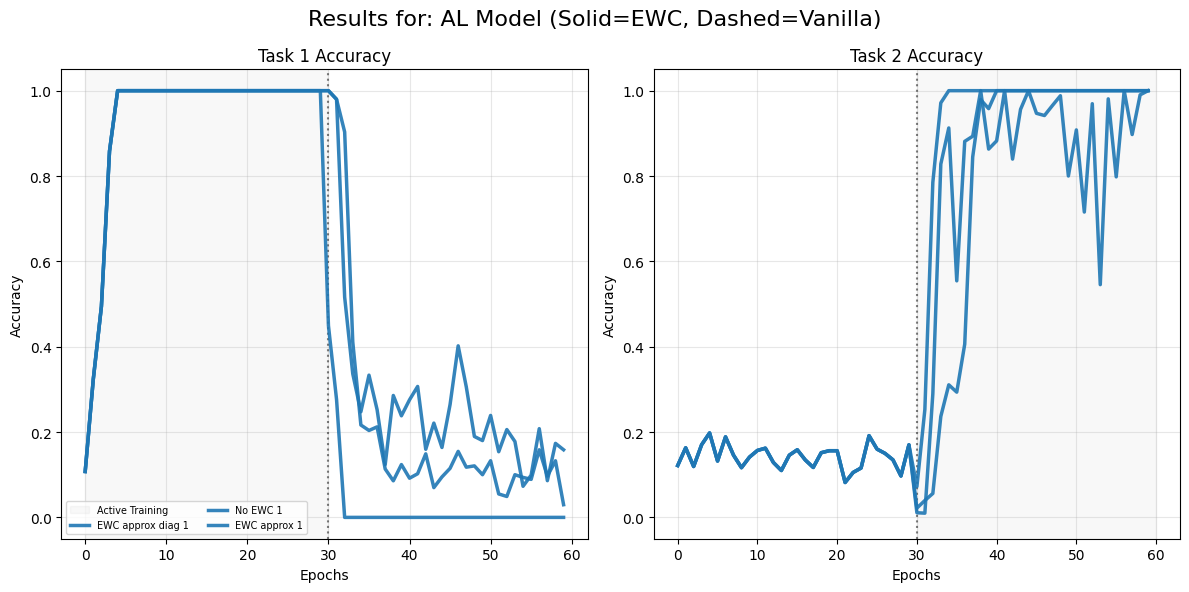

Plot saved to: plots/al_model_results.png


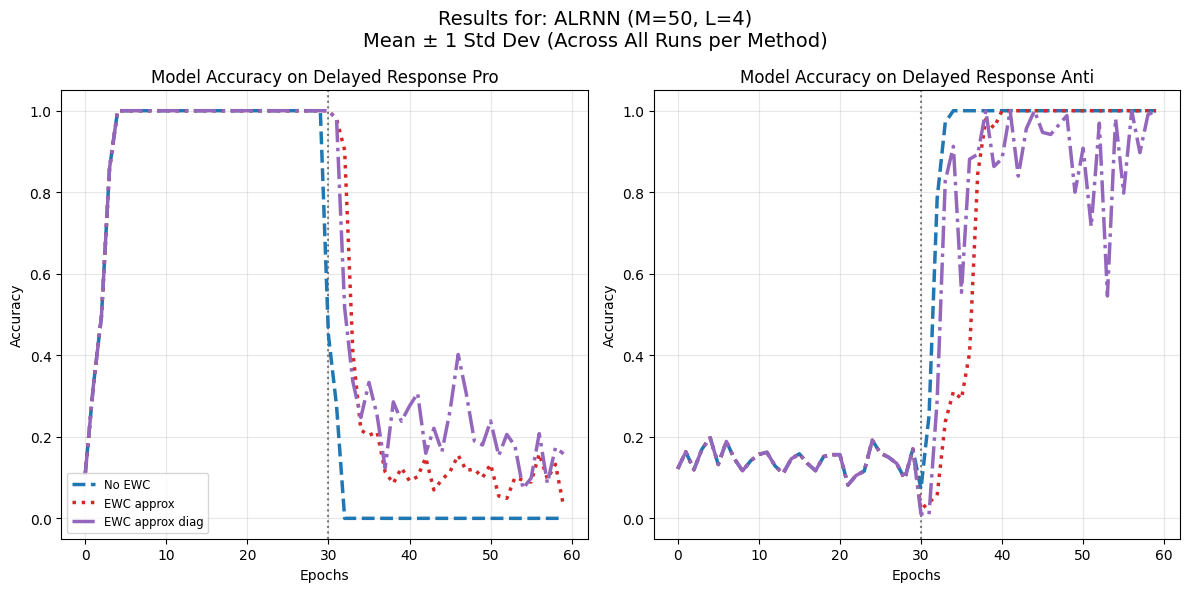

In [60]:
# ==========================================
# 2. Define Tasks and Model Configurations
# ==========================================
params = {'context': (5, 10), 'stimulus': (10, 15), 'delay': (10, 15), 'response': (5, 10)}
tasks = [DelayedResponse(params, mode='pro'),
         DelayedResponse(params, mode='anti')]
M= 50 
L= 4

def get_model_al():
    return PLRNN(M=M, L=L, N=3, input_dim= 9 + len(tasks)) 

def get_model_fully():
    return PLRNN(M=100, L=100, N=3, input_dim=11)

model_configs = {
    "AL Model": get_model_al,
    # "Fully Latent Model": get_model_fully  # Uncomment to test both models sequentially
}

# ==========================================
# 3. Experiment Hyperparameters
# ==========================================
num_repeats = 1
epochs_per_task = 30  
num_tasks = len(tasks)

# Define the dense EWC configuration
ewc_config = {
    'lambda_ewc': 1e2,
    'method': 'tf_full',         # Options: 'tf_full', 'multistep_windowed', 'one_step', 'empirical'
    'n_interleave': 5,          # Window length / TF reset interval
    'alpha': 0.8,                # Teacher forcing strength (if method='tf_full')
    'sigma2': 5.0                # Observation noise variance
}
ewc_last_step_config = ewc_config.copy()
ewc_last_step_config['method'] = 'last_step'  # Use the last step
ewc_last_step_config['lambda_ewc'] = 1e1  

ewc_config_approx = ewc_config.copy()
ewc_config_approx['method'] = 'empirical'  # Use the empirical approximation
ewc_config_approx['lambda_ewc'] = 1e3  # Increase lambda for the weaker approximation

ewc_config_approx_diag = ewc_config.copy()
ewc_config_approx_diag['method'] = 'empirical_diag' 
ewc_config_approx_diag['lambda_ewc'] = 1e4  

# ==========================================
# 4. Run Experiment Loop
# ==========================================
for model_name, model_init_fn in model_configs.items():
    print(f"\n{'='*50}")
    print(f">>> STARTING BATCH FOR: {model_name}")
    print(f"{'='*50}")
    
    # Store results specifically for this model type
    results = {}
    
    # --- Run Experiments ---
    for i in range(1, num_repeats + 1):
        set_seed(i)  # Reset to the exact same seed to compare identical weight initializations
        print(f"\n   Running EWC approx diag {i}/{num_repeats}...")
        results[f'EWC approx diag {i}'], model_diag_empirical = train_experiment(
            model_init_fn=model_init_fn, 
            tasks=tasks, 
            device=device, 
            ewc_params=ewc_config_approx_diag,  # EWC enabled with last step config
            epochs_per_task=epochs_per_task
        )
        '''
        set_seed(i)  # Reset to the exact same seed to compare identical weight initializations
        print(f"\n   Running EWC ls {i}/{num_repeats}...")
        results[f'EWC ls {i}'], model_last_step = train_experiment(
            model_init_fn=model_init_fn, 
            tasks=tasks, 
            device=device, 
            ewc_params=ewc_last_step_config,  # EWC enabled with last step config
            epochs_per_task=epochs_per_task
        )
        '''
        set_seed(i)  # Ensure deterministic start for fair comparison
        print(f"\n   Running No EWC {i}/{num_repeats}...")
        results[f'No EWC {i}'], model_vanilla = train_experiment(
            model_init_fn=model_init_fn, 
            tasks=tasks, 
            device=device, 
            ewc_params=None,  # EWC disabled
            epochs_per_task=epochs_per_task
        )
        
        set_seed(i)  # Reset to the exact same seed to compare identical weight initializations
        print(f"\n   Running EWC Approx {i}/{num_repeats}...")
        results[f'EWC approx {i}'], model_ewc_approx = train_experiment(
            model_init_fn=model_init_fn, 
            tasks=tasks, 
            device=device, 
            ewc_params=ewc_config_approx,  # EWC enabled with full config
            epochs_per_task=epochs_per_task
        )
        '''
        set_seed(i)  # Reset to the exact same seed to compare identical weight initializations
        print(f"\n   Running EWC tf full {i}/{num_repeats}...")
        results[f'EWC {i}'], model_ewc = train_experiment(
            model_init_fn=model_init_fn, 
            tasks=tasks, 
            device=device, 
            ewc_params=ewc_config,  # EWC enabled with full config
            epochs_per_task=epochs_per_task
        )'''
    model_params = {
    'M':M,
    'L':L,
}
task_names = ['Delayed Response Pro', 'Delayed Response Anti']
# --- Visualization for this model type ---
print(f"\nGenerating plots for {model_name}...")
plot_multitask_results(results, model_name, num_tasks=num_tasks)
plot_method_averages(results, num_tasks=num_tasks, model_params=model_params, task_names=task_names)

In [61]:
'''results_approx = {k: v for k, v in results.items() if 'approx' in k or 'No EWC' in k}
results_approx_vs_cf = {k: v for k, v in results.items() if ('approx' in k or 'ls' in k or 'No EWC' in k) and not 'diag' in k}
task_names_4 = ['Delayed Response Pro',
                'Delayed Response Anti',
                'Reaction Time Pro',
                'Reaction Time Anti']
plot_method_averages(results_approx, num_tasks=num_tasks, model_params=model_params, task_names=task_names_4)
plot_method_averages(results_approx_vs_cf, num_tasks=num_tasks, model_params=model_params, task_names=task_names_4)
'''

"results_approx = {k: v for k, v in results.items() if 'approx' in k or 'No EWC' in k}\nresults_approx_vs_cf = {k: v for k, v in results.items() if ('approx' in k or 'ls' in k or 'No EWC' in k) and not 'diag' in k}\ntask_names_4 = ['Delayed Response Pro',\n                'Delayed Response Anti',\n                'Reaction Time Pro',\n                'Reaction Time Anti']\nplot_method_averages(results_approx, num_tasks=num_tasks, model_params=model_params, task_names=task_names_4)\nplot_method_averages(results_approx_vs_cf, num_tasks=num_tasks, model_params=model_params, task_names=task_names_4)\n"

In [62]:
plot_method_averages(results, model_name, num_tasks=num_tasks)

TypeError: plot_method_averages() got multiple values for argument 'num_tasks'

Plot saved to: plots/al_model_results.png


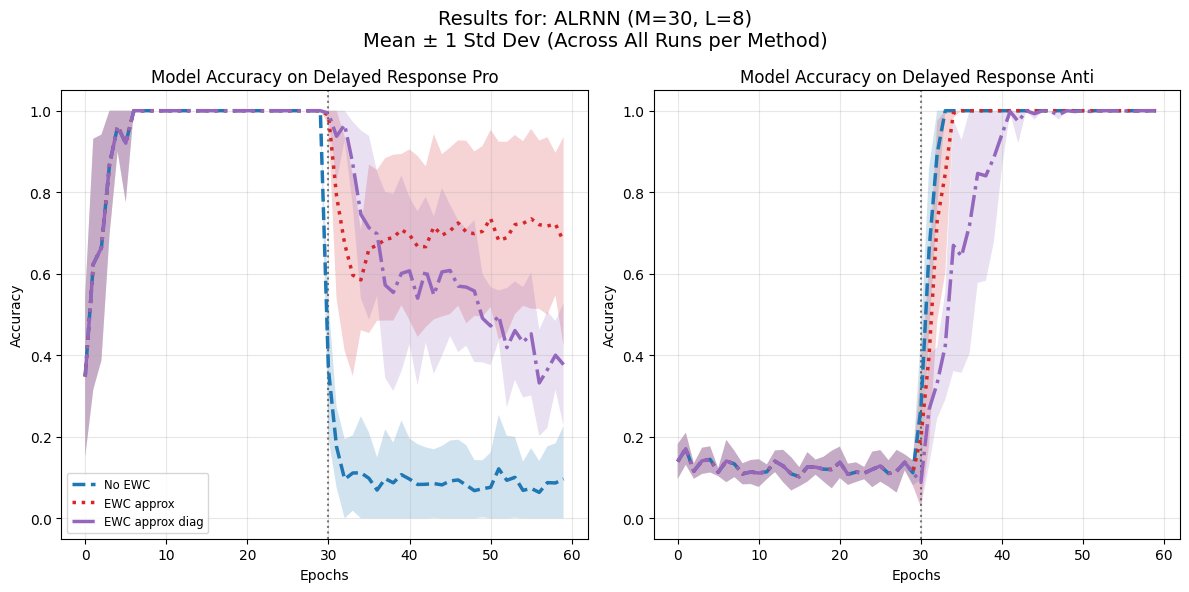

Plot saved to: plots/al_model_results.png


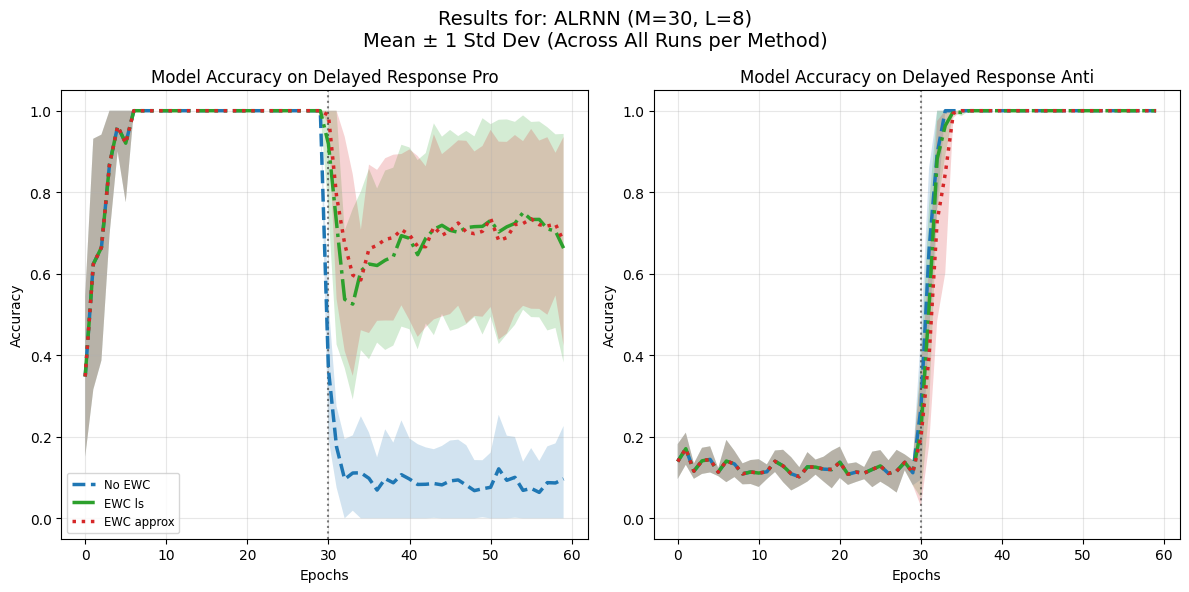

In [ ]:
'''results_approx = {k: v for k, v in results.items() if 'approx' in k or 'No EWC' in k}
results_approx_vs_cf = {k: v for k, v in results.items() if ('approx' in k or 'ls' in k or 'No EWC' in k) and not 'diag' in k}
model_params = {
    'M':30,
    'L':8,
}
task_names = ['Delayed Response Pro', 'Delayed Response Anti']
plot_method_averages(results_approx, num_tasks=num_tasks, model_params=model_params, task_names=task_names)
plot_method_averages(results_approx_vs_cf, num_tasks=num_tasks, model_params=model_params, task_names=task_names)'''

Plot saved to: plots/al_model_results.png


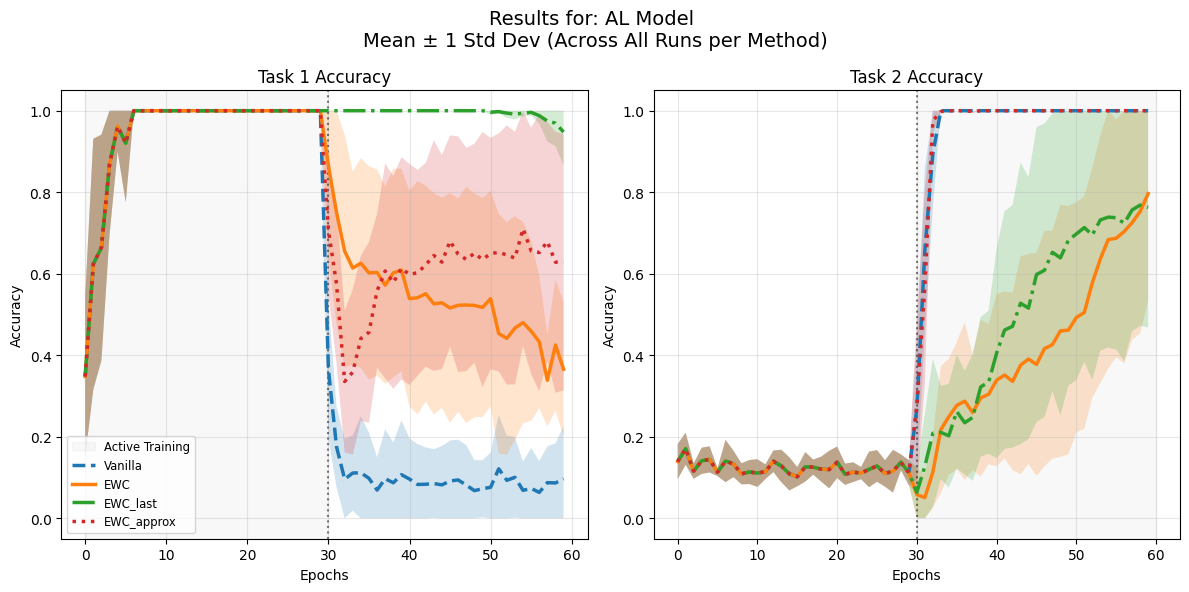

In [ ]:
plot_method_averages(results, model_name, num_tasks=num_tasks)

In [ ]:
fisher_ewc = results['EWC 1']['Fisher'][0]
fisher_ewc_last_step = results['EWC Last Step 1']['Fisher'][0]

In [ ]:
print(fisher_ewc.shape)
print(fisher_ewc_last_step.shape)

torch.Size([1358, 1358])
torch.Size([1358, 1358])


Shape check: torch.Size([1358, 1358]) vs torch.Size([1358, 1358])


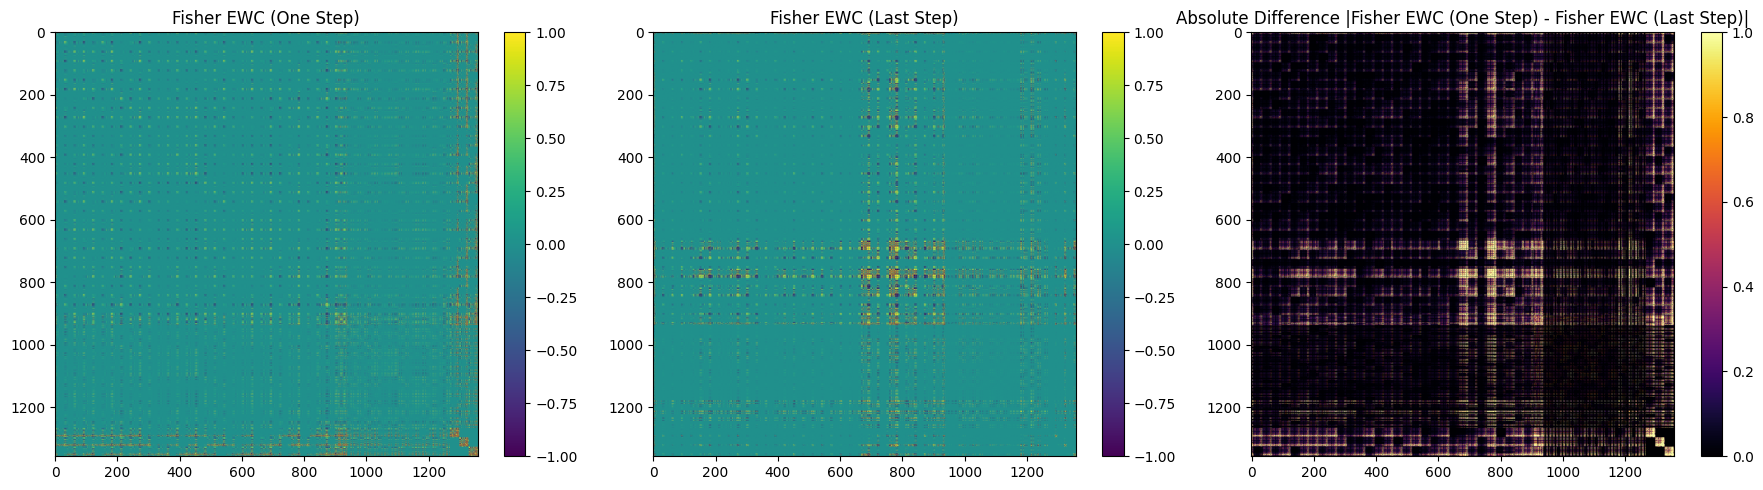

Comparison Metrics
Cosine Similarity:       0.0852 (1.0 = Identical direction)
Frobenius Norm Diff:     3227.9316 (0.0 = Identical matrices)

Value Statistics:
F_EWC      | Mean: 0.0035, Max: 287.9242, Min: -145.8970
F_LastStep | Mean: 0.0152, Max: 429.1076, Min: -108.1746


In [ ]:
def plot_fisher_comparison(F1, F2, title1="Fisher EWC", title2="Fisher EWC Last Step"):
    # Move to CPU and convert to numpy for plotting
    f1_np = F1.cpu().numpy()
    f2_np = F2.cpu().numpy()
    
    # 1. Visual Comparison (Heatmaps)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Use the same color scale for fair comparison, based on the data range
    vmin = min(-10, 10)
    vmax = max(-10, 10)
    # Plot F1
    im1 = axes[0].imshow(f1_np, cmap='viridis', aspect='auto' , vmin=-1, vmax=1)
    axes[0].set_title(title1)
    fig.colorbar(im1, ax=axes[0])
    
    # Plot F2
    im2 = axes[1].imshow(f2_np, cmap='viridis', aspect='auto', vmin=-1, vmax=1)
    axes[1].set_title(title2)
    fig.colorbar(im2, ax=axes[1])
    
    # Plot Difference
    im3 = axes[2].imshow(np.abs(f1_np - f2_np), cmap='inferno', aspect='auto', vmin=0, vmax =1)
    axes[2].set_title(f"Absolute Difference |{title1} - {title2}|")
    fig.colorbar(im3, ax=axes[2])
    
    plt.tight_layout()
    plt.show()

def compute_fisher_similarity(F1, F2):
    # Flatten matrices
    f1_flat = F1.view(-1)
    f2_flat = F2.view(-1)
    
    # Cosine Similarity
    cosine_sim = F.cosine_similarity(f1_flat.unsqueeze(0), f2_flat.unsqueeze(0))
    
    # Frobenius Norm of difference
    diff_norm = torch.norm(F1 - F2, p='fro')
    
    return cosine_sim.item(), diff_norm.item()

# --- Execute Visualization and Metric Calculation ---
print(f"Shape check: {fisher_ewc.shape} vs {fisher_ewc_last_step.shape}")

# Plot
plot_fisher_comparison(fisher_ewc, fisher_ewc_last_step, 
                       title1="Fisher EWC (One Step)", 
                       title2="Fisher EWC (Last Step)")

# Metrics
sim_score, frob_diff = compute_fisher_similarity(fisher_ewc, fisher_ewc_last_step)

print(f"{'='*40}")
print(f"Comparison Metrics")
print(f"{'='*40}")
print(f"Cosine Similarity:       {sim_score:.4f} (1.0 = Identical direction)")
print(f"Frobenius Norm Diff:     {frob_diff:.4f} (0.0 = Identical matrices)")

# Check sparsity or value distribution
print(f"\nValue Statistics:")
print(f"F_EWC      | Mean: {fisher_ewc.mean():.4f}, Max: {fisher_ewc.max():.4f}, Min: {fisher_ewc.min():.4f}")
print(f"F_LastStep | Mean: {fisher_ewc_last_step.mean():.4f}, Max: {fisher_ewc_last_step.max():.4f}, Min: {fisher_ewc_last_step.min():.4f}")

## Bitcode Distributions

In [ ]:
---

In [63]:
params = {'context': (9, 10), 'stimulus': (14, 15), 'delay': (14, 15), 'response': (9, 10)}
tasks = [DelayedResponse(params, mode='pro'),
         DelayedResponse(params, mode='anti')]

task_A_dataset = ContinuousMultitaskDataset(tasks, n_trials=1000)
task_B_dataset = ContinuousMultitaskDataset(tasks, n_trials=1000)
#bitcode_loader = DataLoader(bitcode_dataset, batch_size=200, shuffle=False, collate_fn=collate_fn)

task_A_dataset.set_active_task(0)  # Activate only Task A
task_A_loader = DataLoader(task_A_dataset, batch_size=200, shuffle=False, collate_fn=collate_fn)

task_B_dataset.set_active_task(1)  # Activate only Task B
task_B_loader = DataLoader(task_B_dataset, batch_size=200, shuffle=False, collate_fn=collate_fn)

task_names = ['Delayed Response Pro', 'Delayed Response Anti']

In [70]:
model_with_ewc_task_A = model_ewc_approx[0]
model_with_ewc_task_AB = model_ewc_approx[1]
models_wo_ewc_task_A = model_vanilla[0]
models_wo_ewc_task_AB = model_vanilla[1]

model_dict = {
    "model_w_ewc_trained_A": model_with_ewc_task_A,
    "model_w_ewc_trained_AB": model_with_ewc_task_AB,
    "models_wo_ewc_trained_A": models_wo_ewc_task_A,
    "models_wo_ewc_trained_AB": models_wo_ewc_task_AB,
}

In [110]:
bitcode_dict_eval_A = {}
bitcode_dict_eval_B = {}

task_names = ["0","1"]
for name, model in model_dict.items():
    reconstructed_model = PLRNN(M=M, L=L, N=3, input_dim=11)
    reconstructed_model.load_state_dict(model)
    latent_state_dict_A, _ = get_latent_states(reconstructed_model, task_A_loader, device, task_names)
    latent_state_dict_B, _ = get_latent_states(reconstructed_model, task_B_loader, device, task_names)
    latent_states_A = latent_state_dict_A[0]
    latent_states_B = latent_state_dict_B[1]

    bitcodes_A = bitcode_distribution(latent_states_A, L=L)
    bitcodes_B = bitcode_distribution(latent_states_B, L=L)

    bitcode_dict_eval_A[f"{name}_eval_A"] = bitcodes_A
    bitcode_dict_eval_B[f"{name}_eval_B"] = bitcodes_B

print(bitcode_dict_eval_A.keys())
print(bitcode_dict_eval_B.keys())

bc_dict_ewc = {
    "Model w EWC, Trained on A, Evaluated on A": bitcode_dict_eval_A["model_w_ewc_trained_A_eval_A"],
    "Model w EWC, Trained on A, Evaluated on B": bitcode_dict_eval_B["model_w_ewc_trained_A_eval_B"],
    "Model w EWC, Trained on A+B, Evaluated on A": bitcode_dict_eval_A["model_w_ewc_trained_AB_eval_A"],
    "Model w EWC, Trained on A+B, Evaluated on B": bitcode_dict_eval_B["model_w_ewc_trained_AB_eval_B"],
}

bc_dict_wo_ewc = {
    "Model wo EWC, Trained on A, Evaluated on A": bitcode_dict_eval_A["models_wo_ewc_trained_A_eval_A"],
    "Model wo EWC, Trained on A, Evaluated on B": bitcode_dict_eval_B["models_wo_ewc_trained_A_eval_B"],
    "Model wo EWC, Trained on A+B, Evaluated on A": bitcode_dict_eval_A["models_wo_ewc_trained_AB_eval_A"],
    "Model wo EWC, Trained on A+B, Evaluated on B": bitcode_dict_eval_B["models_wo_ewc_trained_AB_eval_B"],
}
print(bc_dict_ewc.keys())
print(bc_dict_wo_ewc.keys())

compare_w_EWC_on_A_B = {
    "Trained on A+B, Eval on A": bc_dict_ewc["Model w EWC, Trained on A+B, Evaluated on A"],
    "Trained on A+B, Eval on B": bc_dict_ewc["Model w EWC, Trained on A+B, Evaluated on B"],
}
compare_wo_EWC_on_A_B = {
    "Trained on A+B, Eval on A": bc_dict_wo_ewc["Model wo EWC, Trained on A+B, Evaluated on A"],
    "Trained on A+B, Eval on B": bc_dict_wo_ewc["Model wo EWC, Trained on A+B, Evaluated on B"],
}
compare_w_n_wo_EWC_on_A = {
    "Trained on A+B with EWC, Eval on B": bc_dict_ewc["Model w EWC, Trained on A+B, Evaluated on A"],
    "Trained on A+B without EWC, Eval on B": bc_dict_wo_ewc["Model wo EWC, Trained on A+B, Evaluated on A"],
}
compare_w_n_wo_EWC_on_B = {
    "Trained on A+B with EWC, Eval on B": bc_dict_ewc["Model w EWC, Trained on A+B, Evaluated on B"],
    "Trained on A+B without EWC, Eval on B": bc_dict_wo_ewc["Model wo EWC, Trained on A+B, Evaluated on B"],
}
compare_all_models_on_A_B = {
        "EWC: Trained on A+B, Eval on A": bc_dict_ewc["Model w EWC, Trained on A+B, Evaluated on A"],
        "EWC: Trained on A+B, Eval on B": bc_dict_ewc["Model w EWC, Trained on A+B, Evaluated on B"],
        "No EWC: Trained on A+B, Eval on A": bc_dict_wo_ewc["Model wo EWC, Trained on A+B, Evaluated on A"],
        "No EWC: Trained on A+B, Eval on B": bc_dict_wo_ewc["Model wo EWC, Trained on A+B, Evaluated on B"],
}

L:4 | Collected latent states for 2 tasks. Shapes: [(1000, 46, 50), (0,)]
L:4 | Collected latent states for 2 tasks. Shapes: [(0,), (1000, 46, 50)]
L:4 | Collected latent states for 2 tasks. Shapes: [(1000, 46, 50), (0,)]
L:4 | Collected latent states for 2 tasks. Shapes: [(0,), (1000, 46, 50)]
L:4 | Collected latent states for 2 tasks. Shapes: [(1000, 46, 50), (0,)]
L:4 | Collected latent states for 2 tasks. Shapes: [(0,), (1000, 46, 50)]
L:4 | Collected latent states for 2 tasks. Shapes: [(1000, 46, 50), (0,)]
L:4 | Collected latent states for 2 tasks. Shapes: [(0,), (1000, 46, 50)]
dict_keys(['model_w_ewc_trained_A_eval_A', 'model_w_ewc_trained_AB_eval_A', 'models_wo_ewc_trained_A_eval_A', 'models_wo_ewc_trained_AB_eval_A'])
dict_keys(['model_w_ewc_trained_A_eval_B', 'model_w_ewc_trained_AB_eval_B', 'models_wo_ewc_trained_A_eval_B', 'models_wo_ewc_trained_AB_eval_B'])
dict_keys(['Model w EWC, Trained on A, Evaluated on A', 'Model w EWC, Trained on A, Evaluated on B', 'Model w EWC, T

In [92]:
def align_bitcode_distributions(distributions_dict):
    """
    Takes a dict of bitcode distributions (e.g., from different models)
    and returns an aligned matrix + labels for comparison.
    """
    all_bitcodes = set()
    for dist in distributions_dict.values():
        all_bitcodes.update(dist.keys())
    
    bitcode_labels = sorted(list(all_bitcodes))
    n_bitcodes = len(bitcode_labels)
    task_names = list(distributions_dict.keys())
    n_tasks = len(task_names)
    
    aligned_matrix = np.zeros((n_tasks, n_bitcodes))
    for idx, (task_id, dist) in enumerate(distributions_dict.items()):
        for i, bitcode in enumerate(bitcode_labels):
            aligned_matrix[idx, i] = dist.get(bitcode, 0.0)
    
    return aligned_matrix, bitcode_labels
        

In [123]:
def plot_bitcode_alignment_heatmap(distributions_dict, title="Bitcode Alignment Heatmap"):
    """
    Takes a dict of bitcode distributions (key=model name, value=dict of bitcode->frequency)
    and plots a heatmap showing how aligned the two distributions are.
    
    For 2 distributions: shows a 2-row heatmap plus a difference row.
    """
    # (Annahme: align_bitcode_distributions ist woanders definiert)
    aligned_matrix, bitcode_labels = align_bitcode_distributions(distributions_dict)
    model_names = list(distributions_dict.keys())
    n_models = len(model_names)
    n_bitcodes = len(bitcode_labels)
    
    # Sort by the first distribution's frequency (descending) for readability
    sort_idx = np.argsort(-aligned_matrix[0])
    aligned_matrix = aligned_matrix[:, sort_idx]
    bitcode_labels = [bitcode_labels[i] for i in sort_idx]
    
    # Only show top N bitcodes for readability
    max_show = min(40, n_bitcodes)
    aligned_show = aligned_matrix[:, :max_show]
    labels_show = bitcode_labels[:max_show]
    
    # IMPROVEMENT: sharex=True sorgt dafür, dass die X-Achse nur einmal (unten) beschriftet wird.
    if n_models == 2:
        fig, axes = plt.subplots(n_models + 1, 1, 
                                figsize=(max(14, max_show * 0.4), 2.5 * (n_models + 1)),
                                sharex=True)
    else:
        fig, axes = plt.subplots(n_models, 1, 
                                figsize=(max(14, max_show * 0.4), 2.5 * n_models),
                                sharex=True)
    
    # IMPROVEMENT: Einen gut sichtbaren Haupttitel setzen
    fig.suptitle(title, fontsize=16, fontweight='bold')
    
    # Plot each distribution
    for idx in range(n_models):
        im = axes[idx].imshow(aligned_show[idx:idx+1], cmap='Blues', aspect='auto', vmin=0, vmax=aligned_show.max())
        #axes[idx].set_yticks([0])
        #axes[idx].set_yticklabels([model_names[idx]], fontsize=10)
        axes[idx].set_yticks([])
        axes[idx].set_title(f"{model_names[idx]}", fontsize=12)
        fig.colorbar(im, ax=axes[idx], fraction=0.015, pad=0.02)
    
    # Plot absolute difference (for 2 models)
    if n_models == 2:
        diff = np.abs(aligned_show[0] - aligned_show[1]).reshape(1, -1)
        im_diff = axes[-1].imshow(diff, cmap='Reds', aspect='auto', vmin=0)
        #axes[-1].set_yticks([0])
        #axes[-1].set_yticklabels(['|Difference|'], fontsize=10)
        axes[-1].set_yticks([])
        axes[-1].set_title("Absolute Difference", fontsize=12)
        fig.colorbar(im_diff, ax=axes[-1], fraction=0.015, pad=0.02)
        
        # Compute summary stats
        cosine_sim = np.dot(aligned_matrix[0], aligned_matrix[1]) / (
            np.linalg.norm(aligned_matrix[0]) * np.linalg.norm(aligned_matrix[1]) + 1e-12)
        overlap = np.sum(np.minimum(aligned_matrix[0], aligned_matrix[1]))
        
        print(f"Cosine Similarity: {cosine_sim:.4f}")
        print(f"Overlap Coefficient: {overlap:.4f}")

    # IMPROVEMENT: X-Achsen-Beschriftung auf dem untersten Plot formatieren
    axes[-1].set_xticks(range(max_show))
    # rotation=45 und ha='right' macht es viel lesbarer als 90 Grad
    axes[-1].set_xticklabels(labels_show, rotation=45, ha='right', fontsize=9)
    
    # IMPROVEMENT: Layout optimieren, damit Titel und Labels nicht abgeschnitten werden
    plt.tight_layout()
    
    # Etwas Platz oben für den suptitle lassen, da tight_layout ihn manchmal überlagert
    plt.subplots_adjust(top=0.90) 
    
    plt.show()

    return aligned_matrix, bitcode_labels

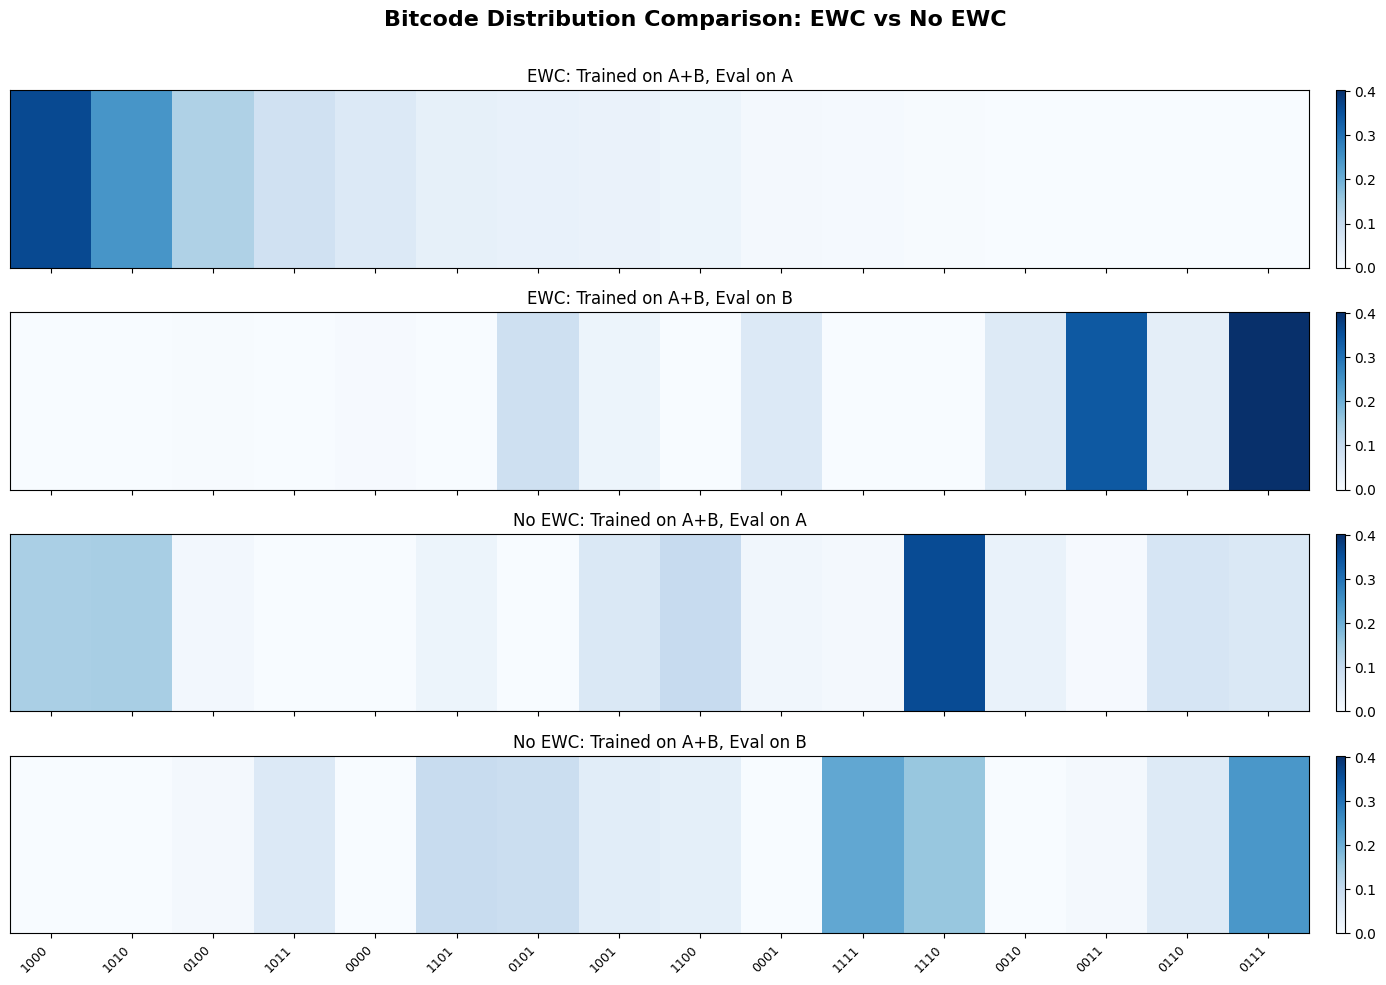

(array([[3.62934783e-01, 2.44782609e-01, 1.29152174e-01, 8.01739130e-02,
         5.38478261e-02, 3.44565217e-02, 3.06956522e-02, 2.56739130e-02,
         2.13043478e-02, 9.41304348e-03, 5.91304348e-03, 1.65217391e-03,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 1.84782609e-03, 0.00000000e+00,
         3.65217391e-03, 0.00000000e+00, 8.43478261e-02, 2.17391304e-02,
         0.00000000e+00, 5.48043478e-02, 0.00000000e+00, 0.00000000e+00,
         5.26521739e-02, 3.39891304e-01, 3.81086957e-02, 4.02956522e-01],
        [1.36695652e-01, 1.37978261e-01, 1.04347826e-02, 3.04347826e-04,
         5.65217391e-04, 2.12173913e-02, 1.08695652e-03, 5.68043478e-02,
         9.78913043e-02, 1.29130435e-02, 8.32608696e-03, 3.60456522e-01,
         2.74347826e-02, 3.73913043e-03, 6.67391304e-02, 5.74130435e-02],
        [0.00000000e+00, 0.00000000e+00, 6.47826087e-03, 5.40652174e-02,
         0.00000000e+00, 9.58043478e-02, 8.98913

In [124]:
plot_bitcode_alignment_heatmap(compare_all_models_on_A_B, title="Bitcode Distribution Comparison: EWC vs No EWC")

Cosine Similarity: 0.0152
Overlap Coefficient: 0.0674


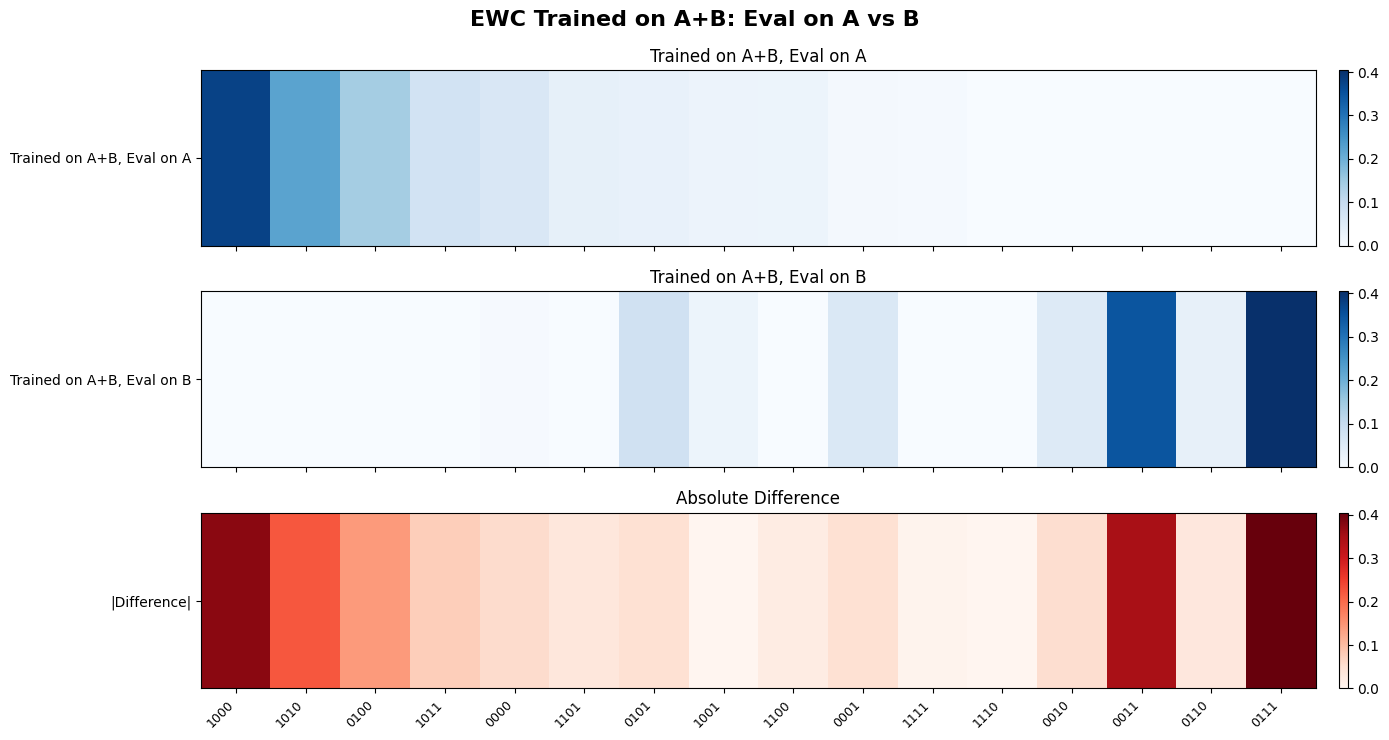

Cosine Similarity: 0.4915
Overlap Coefficient: 0.3848


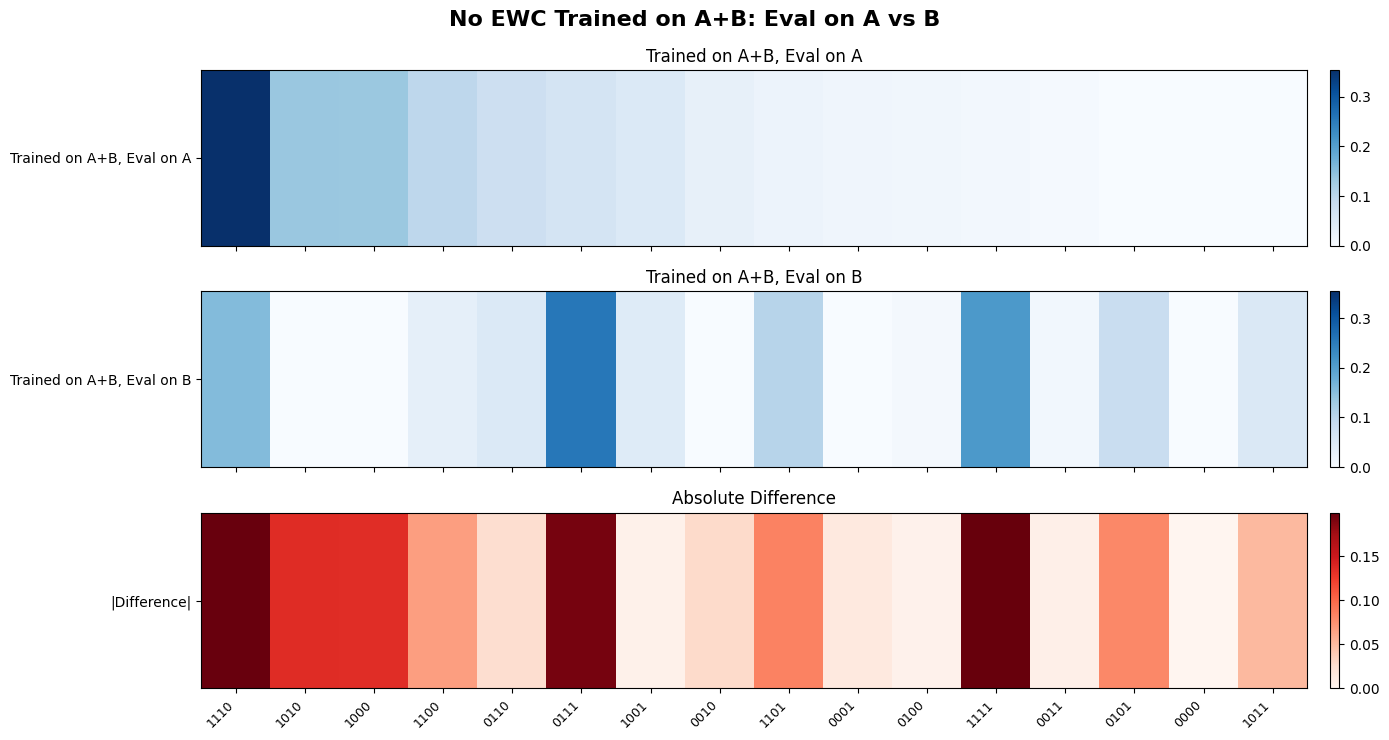

Cosine Similarity: 0.4281
Overlap Coefficient: 0.3641


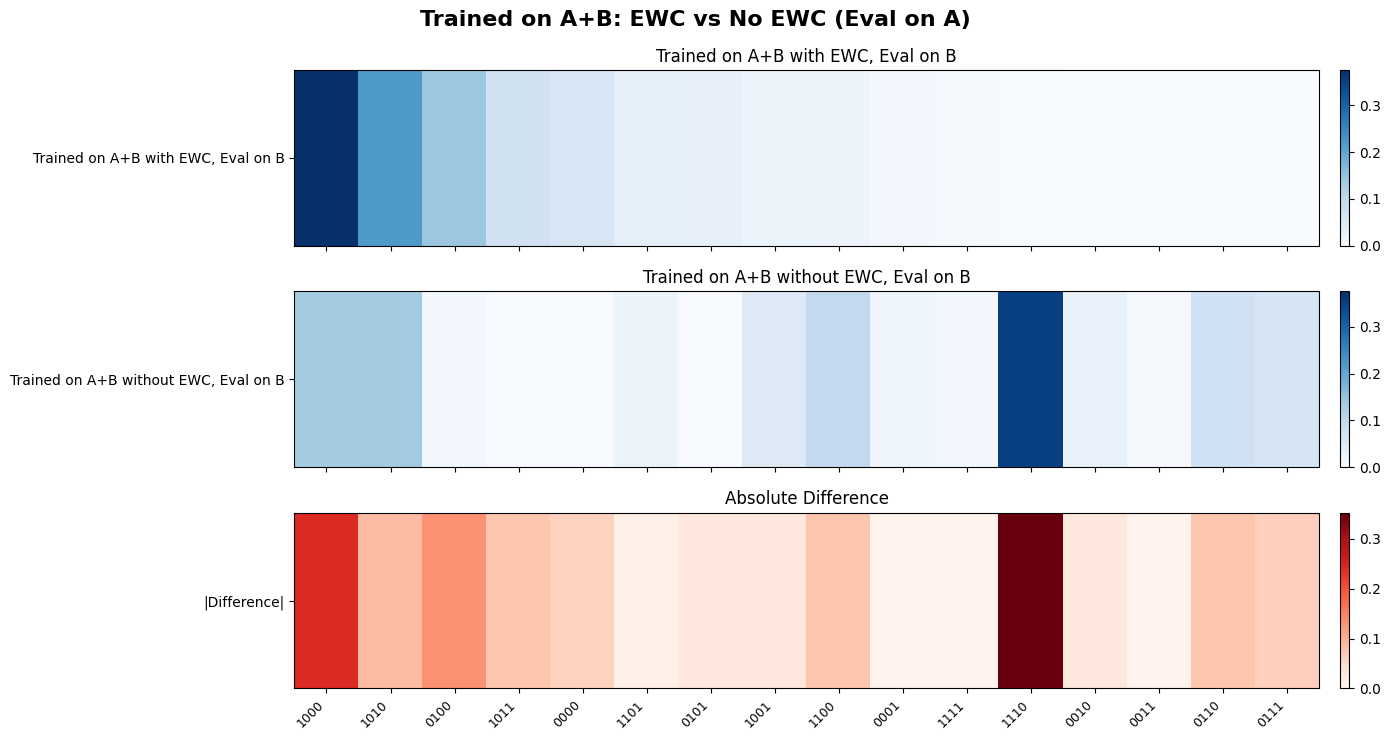

Cosine Similarity: 0.5346
Overlap Coefficient: 0.4021


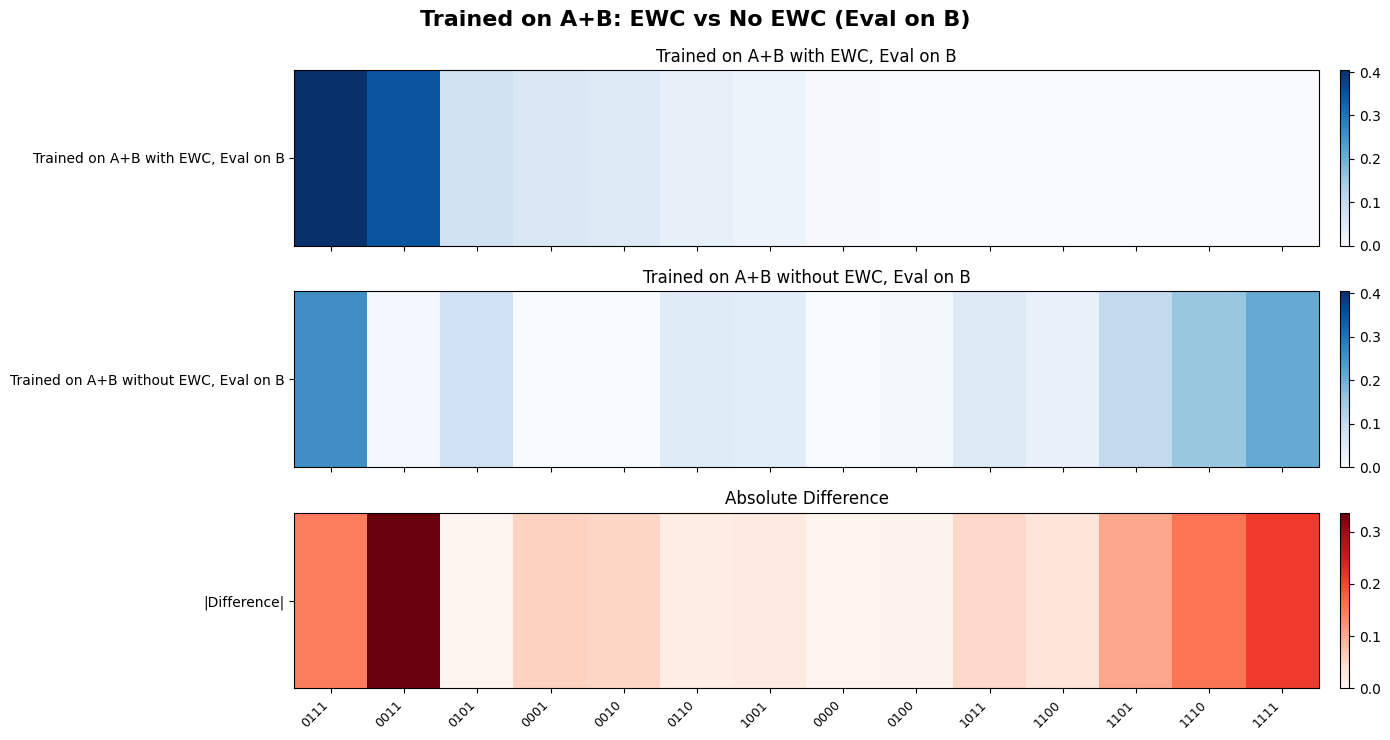

In [101]:
plot_bitcode_alignment_heatmap(compare_w_EWC_on_A_B, title="EWC Trained on A+B: Eval on A vs B")
plot_bitcode_alignment_heatmap(compare_wo_EWC_on_A_B, title="No EWC Trained on A+B: Eval on A vs B")
plot_bitcode_alignment_heatmap(compare_w_n_wo_EWC_on_A, title="Trained on A+B: EWC vs No EWC (Eval on A)")
plot_bitcode_alignment_heatmap(compare_w_n_wo_EWC_on_B, title="Trained on A+B: EWC vs No EWC (Eval on B)")
print()

# Weight Comparison

In [ ]:
---

In [130]:
model_w_ewc_task_A = model_ewc_approx[0]
model_w_ewc_task_AB = model_ewc_approx[1]
model_wo_ewc_task_A = model_vanilla[0]
model_wo_ewc_task_AB = model_vanilla[1]

In [128]:
def plot_weight_comparison(model_state_1, model_state_2, title1="Before EWC", title2="After EWC"):
    """
    Plots heatmaps of weight matrices side-by-side for two model states.
    Calculates and displays the absolute difference.
    """
    # Filter for relevant weight parameters (ignoring scalar buffers if any)
    keys = [k for k in model_state_1.keys() if 'weight' in k or k in ['A', 'W', 'h', 'C', 'D']]
    
    n_params = len(keys)
    if n_params == 0:
        print("No matching parameters found to plot.")
        return

    fig, axes = plt.subplots(n_params, 3, figsize=(15, 3 * n_params))
    if n_params == 1: axes = [axes] # Handle single parameter case

    for i, key in enumerate(keys):
        # Extract tensors and convert to numpy
        w1 = model_state_1[key].cpu().detach().numpy()
        w2 = model_state_2[key].cpu().detach().numpy()
        
        # Determine shared scale for visualization
        vmin = min(w1.min(), w2.min())
        vmax = max(w1.max(), w2.max())
        
        # 1. First Model
        # Handle 1D vectors (like A or h) by expanding dims for imshow
        if w1.ndim == 1:
            im1 = axes[i][0].imshow(w1[np.newaxis, :], cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
        else:
            im1 = axes[i][0].imshow(w1, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
        axes[i][0].set_title(f"{key} ({title1})")
        axes[i][0].set_ylabel(key)
        fig.colorbar(im1, ax=axes[i][0], fraction=0.046, pad=0.04)

        # 2. Second Model
        if w2.ndim == 1:
            im2 = axes[i][1].imshow(w2[np.newaxis, :], cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
        else:
            im2 = axes[i][1].imshow(w2, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
        axes[i][1].set_title(f"{key} ({title2})")
        fig.colorbar(im2, ax=axes[i][1], fraction=0.046, pad=0.04)

        # 3. Difference
        diff = np.abs(w1 - w2)
        if diff.ndim == 1:
            im3 = axes[i][2].imshow(diff[np.newaxis, :], cmap='inferno', aspect='auto')
        else:
            im3 = axes[i][2].imshow(diff, cmap='inferno', aspect='auto')
        axes[i][2].set_title(f"|Difference| {key}")
        
        # Calculate Frobenius Norm of difference for this layer
        diff_norm = np.linalg.norm(diff)
        axes[i][2].set_xlabel(f"L2 Diff: {diff_norm:.4f}")
        fig.colorbar(im3, ax=axes[i][2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


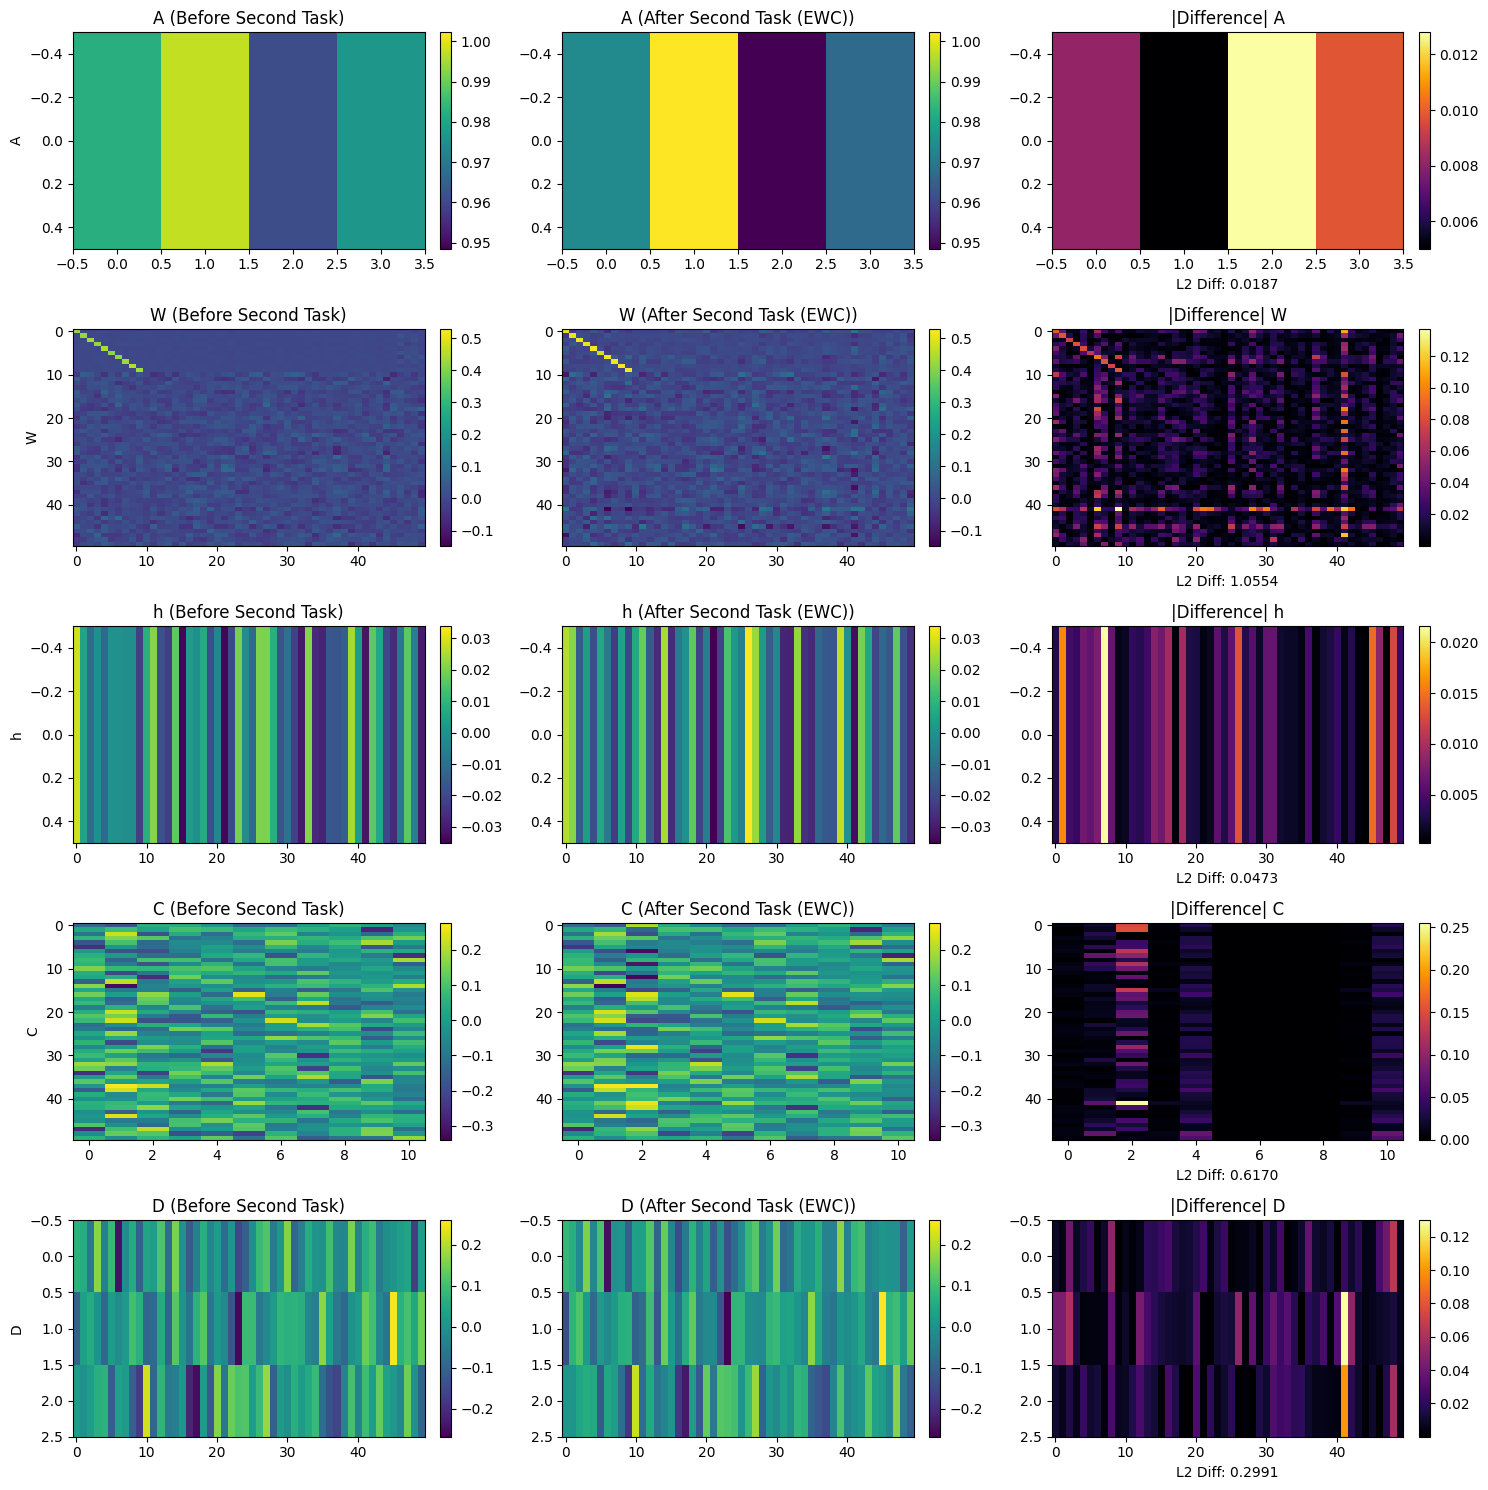

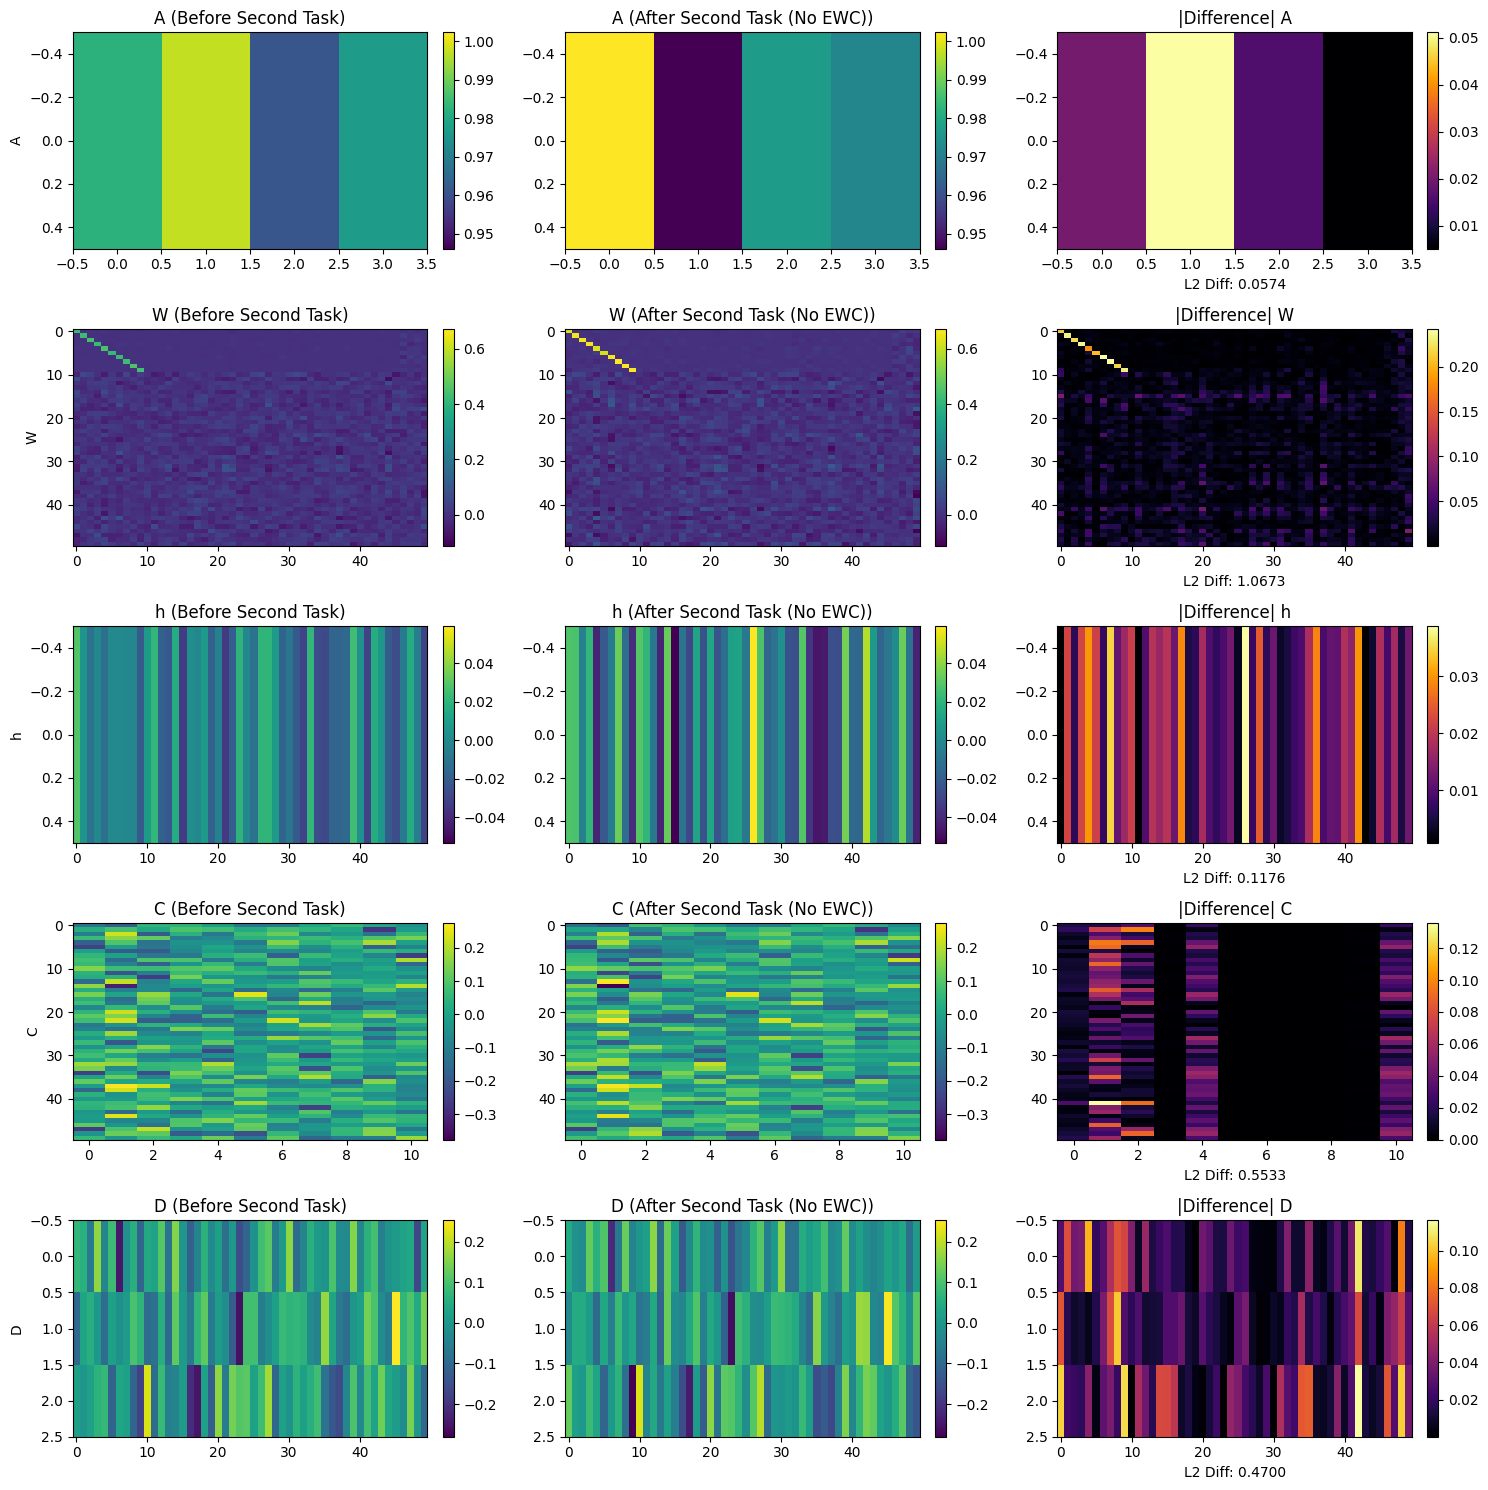

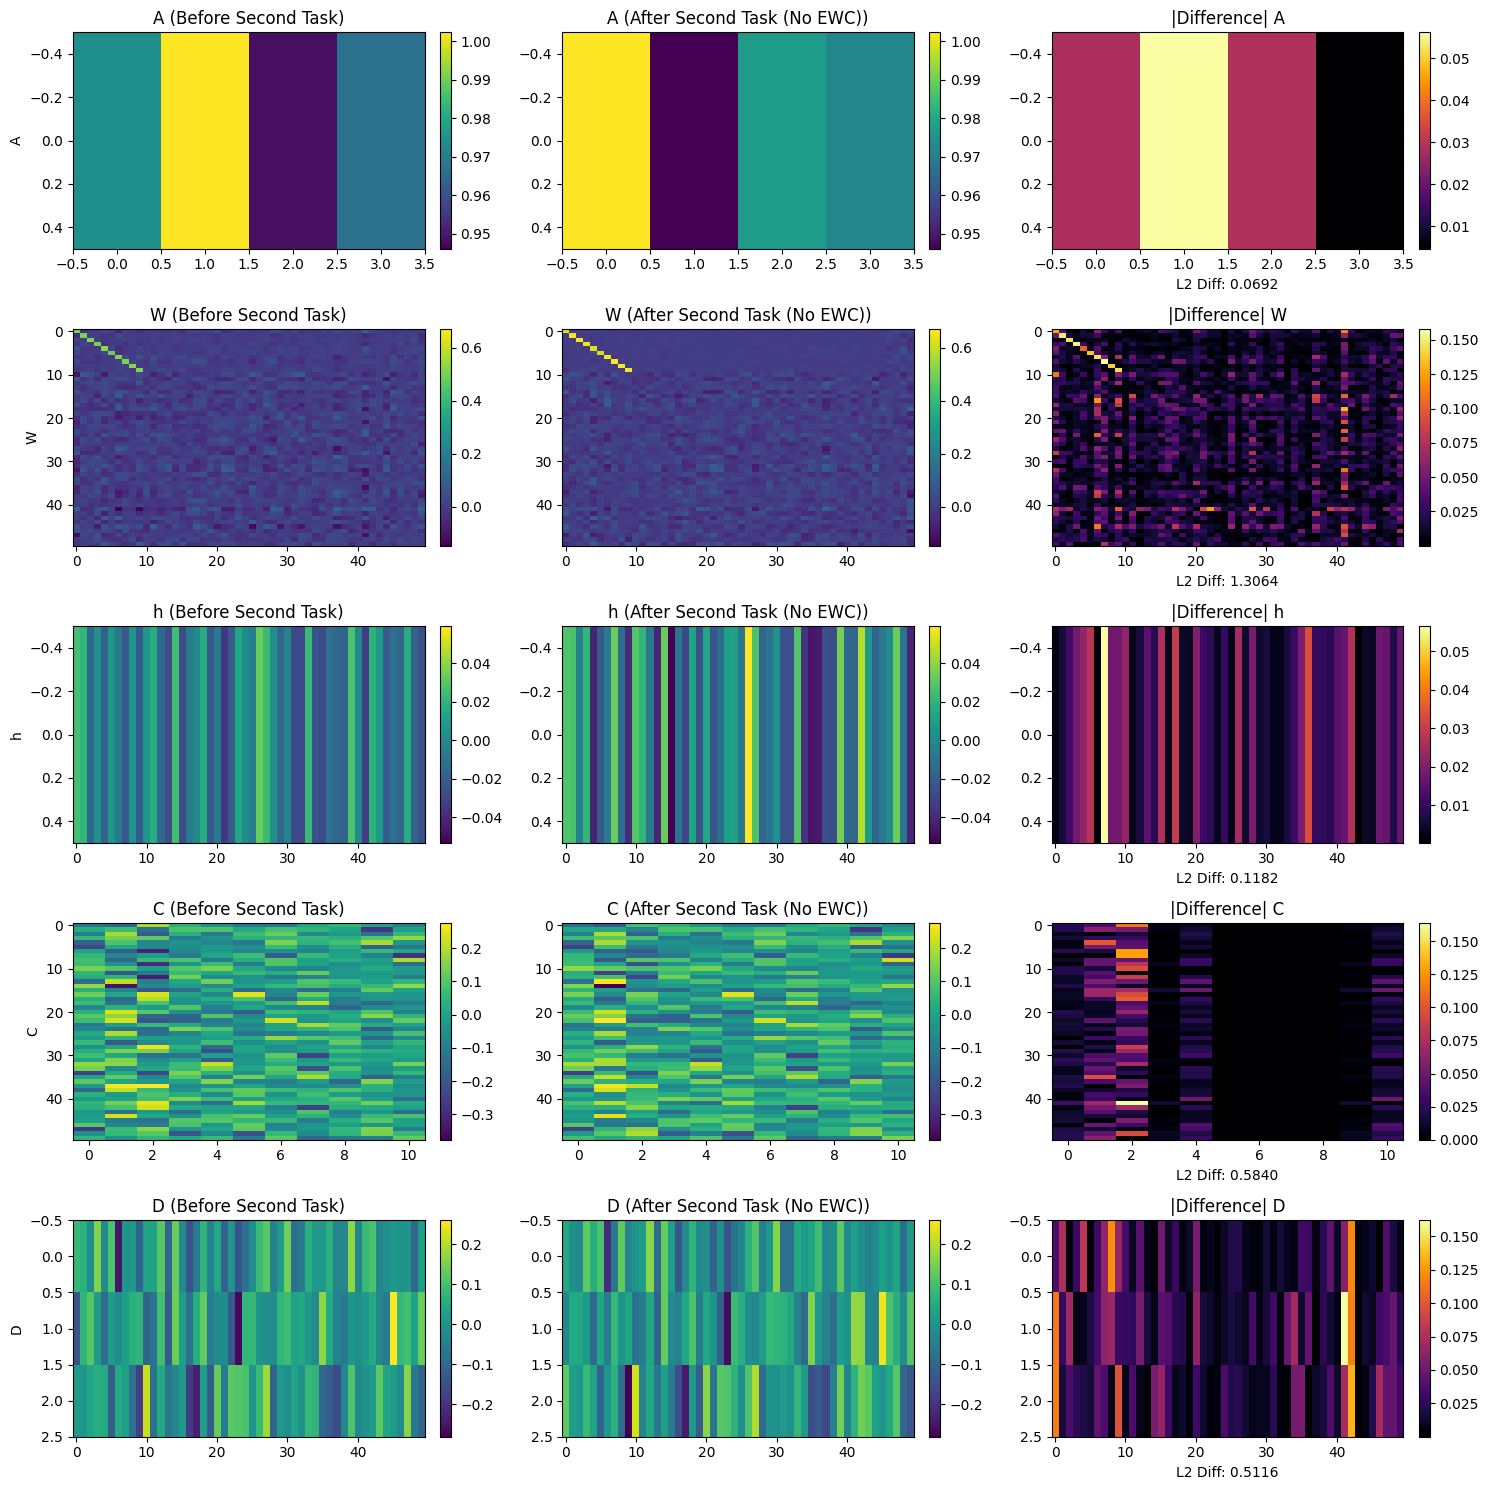

In [131]:
plot_weight_comparison(model_w_ewc_task_A, model_w_ewc_task_AB, 
                       title1="Before Second Task", 
                       title2="After Second Task (EWC)")
plot_weight_comparison(model_wo_ewc_task_A, model_wo_ewc_task_AB,
                       title1="Before Second Task",
                       title2="After Second Task (No EWC)")
plot_weight_comparison(model_w_ewc_task_AB, model_wo_ewc_task_AB,
                       title1="Before Second Task",
                       title2="After Second Task (No EWC)")

# Copy Task

In [162]:
params={'context': (9, 10), 'stimulus': (14, 15), 'delay': (49, 50), 'response': (9, 10)}
pattern_dim = 1
pattern_length = 2

In [163]:
copy_task = CopyTask(duration_params=params, pattern_dim=pattern_dim, pattern_length=pattern_length)
delayed_response_task = DelayedResponse(params, mode='pro')
reaction_time_task = ReactionTime(params, mode='anti')
train_dataset = ContinuousMultitaskDataset([copy_task], n_trials=1000)
train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True, collate_fn=collate_fn)

In [164]:
def get_model_al():
    return PLRNN(M=100, L=100, N=(pattern_length, pattern_dim), input_dim= 10)

model = get_model_al().to(device)
ewc_config = {
    'lambda_ewc': 1e3,
    'method': 'tf_full',         # Options: 'tf_full', 'multistep_windowed', 'one_step', 'empirical'
    'n_interleave': 5,          # Window length / TF reset interval
    'alpha': 0.8,
}

In [165]:
# Custom training loop for CopyTask
print(f"Starting custom training on {copy_task.__class__.__name__}...")

# 1. Setup
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss(reduction='none')
epochs = 60
loss_history = []

# 2. Training Loop
model.train()
for epoch in range(epochs):
    epoch_loss = 0
    num_batches = 0
    
    for inputs, targets, mask, _ in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        # The model outputs the full sequence, but for CopyTask 
        # the collate_fn/dataset usually aligns targets to the output dimension
        outputs = model(inputs) 
        
        unreduced_loss = criterion(outputs, targets)

        mask_expanded = mask.unsqueeze(-1).expand_as(unreduced_loss)
        loss = (unreduced_loss * mask_expanded).sum() / mask_expanded.sum()
        
        loss.backward()
        
        # Gradient clipping to ensure stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
        
    avg_loss = epoch_loss / num_batches
    loss_history.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss (Pattern Difference): {avg_loss:.6f}")

# 3. Visualize Training Loss
plt.figure(figsize=(8, 4))
plt.plot(loss_history[5:], label='Pattern MSE Loss')
plt.title("Copy Task Training - Pattern Convergence")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Visualize one sample batch to see the pattern match
model.eval()
with torch.no_grad():
    # Grab a single batch
    for inputs, targets, _, _ in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        output = model(inputs)
        break # Just need one batch

print("Sample Pattern Comparison (First item in batch):")
print(f"Target Pattern:\n{targets[0].cpu().numpy()}")
print(f"Output Pattern:\n{output[0].cpu().numpy()}")

Starting custom training on CopyTask...


RuntimeError: The expanded size of the tensor (2) must match the existing size (81) at non-singleton dimension 1.  Target sizes: [10, 2, 1].  Tensor sizes: [10, 81, 1]